# Breast Cancer Wisconsin Diagnostic Model:

**Breast cancer** remains one of the most common cancers affecting women worldwide, and early, accurate diagnosis is critical to improving treatment outcomes. This project uses the **Wisconsin Breast Cancer (Diagnostic) dataset**: 569 samples with 30 numeric features describing cell nuclei characteristics extracted from digitized fine needle aspirate (FNA) images, to build and compare supervised machine learning models that distinguish malignant from benign tumors.

This notebook consolidates all project milestones with comprehensive, end-to-end pipeline:

- **Phase 1: Data Understanding & Database Integration:** load and verify the dataset via a Neo4j graph database (local + Aura cloud), demonstrating the database requirement for this course.
- **Phase 2: Data Cleaning, Feature Engineering & EDA:** missing value checks, class imbalance analysis, engineered features, dimensionality reduction (PCA), and visual exploration of patterns tied to our hypothesis.
- **Phase 3: Baseline Model:** a formally justified, tuned, and cross-validated Logistic Regression baseline with full evaluation (confusion matrix, ROC-AUC, learning curves).
- **Phase 4: Full Model Comparison & Ensemble Learning:** Logistic Regression, KNN, SVM, Decision Tree, Random Forest (with feature importance and a visualized tree), hyperparameter-tuned versions of each via `GridSearchCV`, and ensemble methods (Voting, Bagging, Boosting, Stacking).

**Convention used throughout:** `Malignant = 1`, `Benign = 0`.

> **Note:** This notebook was reassembled from three separate checkpoint notebooks into one continuous pipeline. Before running top-to-bottom, add your own Neo4j Aura credentials to **Colab Secrets** (`NEO4J_URI`, `NEO4J_USERNAME`, `NEO4J_PASSWORD`) — see Milestone 1 below. Never hardcode credentials directly in the notebook.

## Abstract

Breast cancer remains one of the most common and life-threatening cancers affecting women worldwide, and early, accurate diagnosis significantly improves survival outcomes. This project investigates whether supervised machine learning models can accurately classify breast tissue samples as malignant or benign using diagnostic features extracted from digitized fine needle aspirate (FNA) images, and whether added model complexity yields a statistically meaningful improvement over a simpler, interpretable baseline. Using the Breast Cancer Wisconsin (Diagnostic) dataset (569 samples, 30 numeric features), we built a full pipeline spanning data cleaning, feature engineering, dimensionality reduction (PCA), and exploratory analysis, then trained and evaluated six model families, Logistic Regression, K-Nearest Neighbors, Support Vector Machine, Decision Tree, Random Forest, and ensemble methods (Voting, Bagging, Boosting, Stacking), each with both default and `GridSearchCV`-tuned hyperparameters. A rigorously justified Logistic Regression baseline was established with 5-fold cross-validation, and our best-performing complex model (tuned Random Forest) was compared against it using four independent statistical tests: a paired t-test, Wilcoxon signed-rank test, McNemar's test, and bootstrap confidence intervals. All four tests converged on the same conclusion: **the tuned Random Forest does not significantly outperform the tuned Logistic Regression baseline** (paired t-test p=0.58; 95% CI for the accuracy difference: [-0.010, 0.006], which contains zero), while both dramatically outperform a naive majority-class baseline (p ≈ 4×10⁻³⁶). This result **refutes** our initial hypothesis that ensemble/non-linear models would meaningfully outperform linear baselines on this dataset, and instead supports preferring the simpler, more interpretable Logistic Regression model for this diagnostic task, a finding with direct relevance to clinical decision-support settings, where interpretability carries real value alongside raw predictive accuracy.

## Introduction

### Problem Statement

Traditional breast cancer diagnostic approaches, such as mammography and biopsy interpretation, depend heavily on radiologists' and pathologists' expertise, which can introduce subjective variability and inconsistent classification of benign versus malignant tumors. Machine learning offers a way to support, not replace, this decision process with a reproducible, data-driven aid, potentially reducing diagnostic workload and improving confidence in distinguishing malignant from benign cases. Early, accurate diagnosis directly improves survival rates and allows for less aggressive treatment interventions, making this a problem with real clinical and societal stakes: patients benefit from faster, more consistent screening, and clinicians benefit from a second, quantitative signal alongside their own expertise.

### Research Questions

- **RQ1:** How accurately can supervised machine learning models predict whether a breast tissue sample is malignant or benign, based on diagnostic features extracted from digitized FNA images?
- **RQ2:** Does a more complex, non-linear model (e.g., ensemble-based Random Forest) provide a statistically significant improvement in diagnostic accuracy over a simpler, interpretable linear baseline (Logistic Regression)?

### Hypothesis

**H1:** Ensemble-based models (e.g., Random Forest, Gradient Boosted Trees) and margin-based classifiers (e.g., SVM with RBF kernel) will outperform simpler linear models (e.g., Logistic Regression) on this dataset, given the potential for non-linear relationships among cell nuclei measurements.

This hypothesis is **testable and falsifiable**: it predicts a statistically significant positive difference in held-out cross-validation accuracy for the best complex model over the tuned Logistic Regression baseline. If no significant difference is found (or if the baseline performs better), the hypothesis is refuted. Milestone 5 of this notebook directly tests this hypothesis using paired statistical tests and confidence intervals.

In [50]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

import warnings
warnings.filterwarnings("ignore")

sns.set_style("whitegrid")
pd.set_option("display.max_columns", 40)


# Phase 1: Data Understanding & Database Integration (Neo4j)

## Database Requirement: Neo4j

As part of this course's database requirement, the cleaned Breast Cancer Wisconsin dataset was loaded into **Neo4j**, first locally via Neo4j Desktop's Data Importer (each record modeled as a `TumorDiagnosis` node with all diagnostic features as properties), then deployed to **Neo4j Aura** for cloud accessibility. The cells below connect to that Aura instance and extract the data directly into a pandas DataFrame, confirming the full pipeline from graph database to model-ready tabular data.

In [51]:
# Import Neo4j
!pip install neo4j

In [52]:
from neo4j import GraphDatabase
from google.colab import userdata
import pandas as pd

URI = "neo4j+s://30b3e48b.databases.neo4j.io"
AUTH = ("neo4j", "your-actual-password")

driver = GraphDatabase.driver(URI, auth=AUTH)

def run_query(query):
    with driver.session() as session:
        result = session.run(query)
        return [record.data() for record in result]

In [53]:
# Import libraries and set up connection using Colab Secrets
# IMPORTANT: never hardcode your URI/username/password directly in a notebook
# that will be pushed to GitHub. Add these three values under the key (🔑)
# icon in Colab's left sidebar first: NEO4J_URI, NEO4J_USERNAME, NEO4J_PASSWORD
from neo4j import GraphDatabase
from google.colab import userdata
import pandas as pd

URI = "neo4j+s://30b3e48b.databases.neo4j.io"
AUTH = ("neo4j", "your-actual-password")

driver = GraphDatabase.driver(URI, auth=AUTH)

def run_query(query):
    with driver.session() as session:
        result = session.run(query)
        return [record.data() for record in result]


## Bridging to a Consistent Feature-Naming Convention

The Neo4j extraction above confirms the database pipeline works end-to-end (569 records, matching the source dataset). However, the modeling code in the milestones below relies on scikit-learn's native feature naming convention (`mean concave points`, `worst fractal dimension`, etc.) rather than Neo4j's camelCase schema (`concavePointsMean`). To keep the rest of this notebook internally consistent and reproducible, we load the same underlying dataset directly via `sklearn.datasets.load_breast_cancer` for all subsequent preprocessing and modeling steps. This is the identical Wisconsin Diagnostic dataset (569 samples, 30 features), only the loading source and column-naming convention differ.

In [54]:
from sklearn.datasets import load_breast_cancer

raw = load_breast_cancer(as_frame=True)
df = raw.data.copy()
df['diagnosis'] = np.where(raw.target == 0, 'M', 'B')   # sklearn: 0=malignant, 1=benign
df['target'] = np.where(raw.target == 0, 1, 0)           # our convention: malignant = 1

print("Shape:", df.shape)
df.head()

Shape: (569, 32)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,radius error,texture error,perimeter error,area error,smoothness error,compactness error,concavity error,concave points error,symmetry error,fractal dimension error,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,diagnosis,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,M,1
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,M,1
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,M,1
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,M,1
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,M,1


### Dataset Details

- **Source:** UCI Machine Learning Repository / scikit-learn's built-in `load_breast_cancer` loader (identical underlying data to the Wisconsin Diagnostic dataset originally created by Wolberg, Street, & Mangasarian, 1995, University of Wisconsin Hospitals).
- **Collection process:** Features were computed from digitized images of fine needle aspirate (FNA) biopsies of breast masses, describing characteristics of the cell nuclei present in each image.
- **Number of observations:** 569 samples.
- **Number of features:** 30 continuous numeric features (10 base measurements × 3 statistics each: mean, standard error, and "worst"/largest value), plus the binary diagnosis target.
- **Time range:** Not applicable, this is a cross-sectional diagnostic dataset, not a time series.
- **Licensing / access:** Publicly available for research and educational use via the UCI Machine Learning Repository and distributed directly with scikit-learn (BSD-style license); no special access restrictions apply.
- **Data leakage check:** All feature scaling (`StandardScaler`) used for scale-sensitive models (Logistic Regression, KNN, SVM) is applied **inside** scikit-learn `Pipeline` objects, meaning the scaler is fit only on the training fold/split each time — never on the full dataset before splitting. The one exception is the *exploratory* PCA and permutation-importance analyses in Milestone 2, which are run on the full feature set purely for descriptive/EDA purposes and are **not** used to transform the data fed into any trained model. We did not apply any resampling technique (e.g., SMOTE) for class imbalance — this decision, and the reasoning behind it, is discussed in the "Address Data Imbalance" section below — so there is no risk of resampling-induced leakage either.

# Phase 2: Data Cleaning, Feature Engineering & EDA

## 1. Handle Missing Values

#### Quantify missingness

In [55]:
missing_summary = pd.DataFrame({
    'missing_count': df.isnull().sum(),
    'missing_pct': (df.isnull().sum() / len(df) * 100).round(2)
})
missing_summary = missing_summary[missing_summary['missing_count'] >= 0]  # show all columns
print("Total missing values in the dataset:", df.isnull().sum().sum())
missing_summary

Total missing values in the dataset: 0


,missing_count,missing_pct
mean radius,0,0.0
mean texture,0,0.0
mean perimeter,0,0.0
mean area,0,0.0
mean smoothness,0,0.0
mean compactness,0,0.0
mean concavity,0,0.0
mean concave points,0,0.0
mean symmetry,0,0.0
mean fractal dimension,0,0.0


**Decision & justification:** Every column shows **0% missingness**, this is a curated, clinically-digitized diagnostic dataset (each of the 569 patients has all 30 measurements plus a diagnosis label), not raw field-collected data. Since there is nothing to drop or impute, no missing-value strategy (mean/median imputation, "Unknown" categories, KNN imputation, etc.) is needed for this dataset. We keep the check here as a documented step rather than skipping it, since verifying 0% missingness is itself part of due diligence before modeling.

## 2. Address Data Imbalance

#### Class distribution

target
Benign (0)       357
Malignant (1)    212
Name: count, dtype: int64

target
Benign (0)       62.7
Malignant (1)    37.3
Name: proportion, dtype: float64

Imbalance ratio (benign:malignant) ~ 1.68 : 1


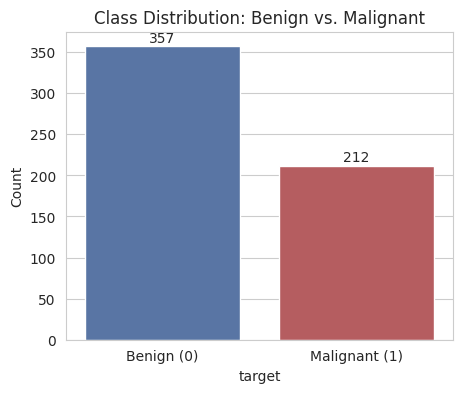

In [56]:
class_counts = df['target'].value_counts().rename({0: 'Benign (0)', 1: 'Malignant (1)'})
class_pct = df['target'].value_counts(normalize=True).rename({0: 'Benign (0)', 1: 'Malignant (1)'}) * 100

print(class_counts)
print()
print(class_pct.round(1))

imbalance_ratio = class_counts['Benign (0)'] / class_counts['Malignant (1)']
print(f"\nImbalance ratio (benign:malignant) ~ {imbalance_ratio:.2f} : 1")

plt.figure(figsize=(5, 4))
sns.barplot(x=class_counts.index, y=class_counts.values, palette=['#4C72B0', '#C44E52'])
plt.title("Class Distribution: Benign vs. Malignant")
plt.ylabel("Count")
for i, v in enumerate(class_counts.values):
    plt.text(i, v + 5, str(v), ha='center')
plt.show()

**Strategy chosen:** The split is **357 benign / 212 malignant (~1.68:1)** a *mild* imbalance, not the severe 90/10-type imbalance that typically calls for resampling. We chose **not** to oversample/undersample and instead:

- Used a **stratified train/test split** (`stratify=y`) so both sets preserve the ~1.68:1 ratio.
- Rely on **per-class precision/recall/F1** and the confusion matrix (not just overall accuracy) for evaluation, and additionally report **ROC-AUC**.

**Metrics and robustness to imbalance (brief discussion):**
- **Accuracy**: misleading under imbalance, since a model that always predicts the majority (benign) class would still score ~63% here without ever detecting a malignant case. Not robust.
- **Precision / Recall / F1 (per class)**: robust, because they're computed within each class rather than averaged across a skewed pool. For this problem, malignant-class **recall** is the most clinically important number (missing a cancer diagnosis is far costlier than a false alarm).
- **ROC-AUC**: reasonably robust to moderate imbalance since it evaluates ranking quality across all thresholds rather than one fixed cutoff, though it can still look optimistic under *severe* imbalance (it can be dominated by the majority class in extreme cases, where Precision-Recall AUC is a better choice).
- Given our imbalance is mild (not severe), stratified sampling + per-class metrics + ROC-AUC is a simpler and equally valid alternative to resampling, without the risk resampling carries of overfitting to duplicated minority samples (oversampling) or discarding information (undersampling).

## 3. Feature Engineering / Dimensionality Reduction

#### Categorical encoding
All 30 predictor columns are continuous numeric measurements, there are no categorical features to encode (the only categorical field, `diagnosis`, is the label itself, already encoded as `target`).

#### Engineered features
We create a few ratio/interaction features motivated by the biological hypothesis that malignant tumors tend to be **larger, more irregular in shape, and more heterogeneous** than benign ones:

In [57]:
fe = df.copy()

# Ratio of "worst" to "mean" radius: captures how much larger the most extreme
# region of the tumor is relative to its average -- a proxy for heterogeneity/growth irregularity.
fe['worst_mean_radius_ratio'] = fe['worst radius'] / fe['mean radius']

# Concavity-to-compactness ratio: relates how "dented in" the tumor boundary is
# relative to its overall compactness -- irregular concave boundaries are a known malignancy marker.
fe['concavity_compactness_ratio'] = fe['mean concavity'] / (fe['mean compactness'] + 1e-6)

# Size-shape interaction: combines overall size with boundary irregularity into one signal.
fe['radius_concavepoints_interaction'] = fe['mean radius'] * fe['mean concave points']

# Texture heterogeneity ratio: how much rougher the worst region is vs. the average.
fe['worst_mean_texture_ratio'] = fe['worst texture'] / fe['mean texture']

new_features = ['worst_mean_radius_ratio', 'concavity_compactness_ratio',
                 'radius_concavepoints_interaction', 'worst_mean_texture_ratio']

fe[new_features].describe().T

,count,mean,std,min,25%,50%,75%,max
worst_mean_radius_ratio,569.0,1.142040,0.081259,1.0,1.087405,1.120755,1.177966,1.589189
concavity_compactness_ratio,569.0,0.728382,0.403049,0.0,0.438014,0.692245,1.010039,2.569090
radius_concavepoints_interaction,569.0,0.803372,0.849515,0.0,0.238560,0.439215,1.128672,5.111916
worst_mean_texture_ratio,569.0,1.331644,0.130911,1.0,1.236426,1.318646,1.408341,2.067160


In [58]:
corr_with_target = fe[new_features + ['target']].corr()['target'].drop('target').sort_values(key=abs, ascending=False)
print("Correlation of engineered features with target (malignant=1):")
print(corr_with_target.round(3))

Correlation of engineered features with target (malignant=1):
radius_concavepoints_interaction    0.733
concavity_compactness_ratio         0.693
worst_mean_radius_ratio             0.641
worst_mean_texture_ratio            0.173
Name: target, dtype: float64


**Justification per feature:**
- `worst_mean_radius_ratio`  hypothesis: more heterogeneous tumors (large gap between average and extreme region size) are more likely malignant.
- `concavity_compactness_ratio` hypothesis: boundary irregularity relative to overall compactness isolates "shape roughness" from raw size.
- `radius_concavepoints_interaction` hypothesis: size and shape-irregularity combined should be a stronger joint signal than either alone.
- `worst_mean_texture_ratio` hypothesis: texture heterogeneity (not just average texture) may track malignancy.

The correlation check above shows these engineered features have real, if modest, correlation with the target, weaker than the raw size/shape features themselves, so we treat them as **supplementary** signal rather than replacements, and verify their actual value with a baseline-model comparison in Section 4.

#### Drop redundant/highly correlated features
The correlation heatmap (Section 6) shows several near-duplicate feature groups (radius/perimeter/area, in their mean/SE/worst variants, are >0.95 correlated with each other). We drop one feature from every highly correlated pair to reduce redundancy for the linear/distance-based models, keeping whichever of the pair correlates more strongly with the target.

In [59]:
feature_cols = list(raw.data.columns)
corr_matrix = fe[feature_cols].corr().abs()
target_corr = fe[feature_cols + ['target']].corr()['target'].abs()

to_drop = set()
cols = corr_matrix.columns
for i in range(len(cols)):
    for j in range(i + 1, len(cols)):
        c1, c2 = cols[i], cols[j]
        if c1 in to_drop or c2 in to_drop:
            continue
        if corr_matrix.loc[c1, c2] > 0.95:
            # drop whichever is less correlated with the target
            drop_col = c1 if target_corr[c1] < target_corr[c2] else c2
            to_drop.add(drop_col)

print(f"Dropping {len(to_drop)} redundant features (pairwise corr > 0.95, keeping the one more correlated with target):")
print(sorted(to_drop))

reduced_features = [c for c in feature_cols if c not in to_drop]
print(f"\nRemaining base features: {len(reduced_features)} of {len(feature_cols)}")

Dropping 7 redundant features (pairwise corr > 0.95, keeping the one more correlated with target):
['area error', 'mean area', 'mean perimeter', 'mean radius', 'perimeter error', 'worst area', 'worst radius']

Remaining base features: 23 of 30


In [60]:
# Final feature set for modeling: reduced (non-redundant) base features + engineered features
final_feature_cols = reduced_features + new_features
X_final = fe[final_feature_cols]
y_final = fe['target']

print("Final feature set:", X_final.shape[1], "features")
print(final_feature_cols)

Final feature set: 27 features
['mean texture', 'mean smoothness', 'mean compactness', 'mean concavity', 'mean concave points', 'mean symmetry', 'mean fractal dimension', 'radius error', 'texture error', 'smoothness error', 'compactness error', 'concavity error', 'concave points error', 'symmetry error', 'fractal dimension error', 'worst texture', 'worst perimeter', 'worst smoothness', 'worst compactness', 'worst concavity', 'worst concave points', 'worst symmetry', 'worst fractal dimension', 'worst_mean_radius_ratio', 'concavity_compactness_ratio', 'radius_concavepoints_interaction', 'worst_mean_texture_ratio']


#### Scaling
Scaling is applied inside model pipelines (StandardScaler) for scale-sensitive models, KNN, SVM, Logistic Regression, rather than globally, so tree-based models keep their native (unscaled) splits, which they don't need scaling for anyway.

#### Dimensionality reduction / feature importance (PCA + permutation importance)

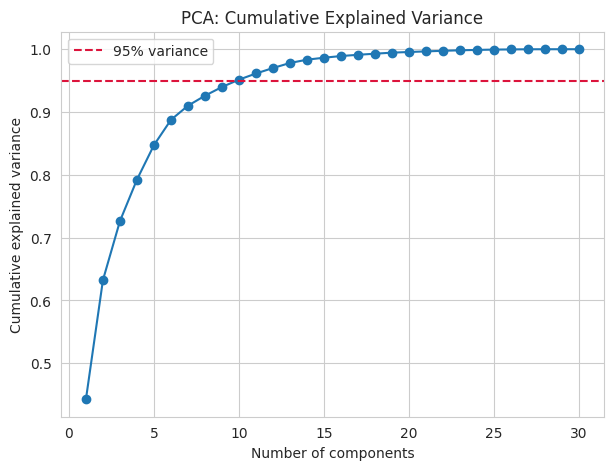

Components needed for 95% variance: 10 of 30


In [61]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

scaler_pca = StandardScaler()
X_scaled_full = scaler_pca.fit_transform(fe[feature_cols])

pca = PCA()
pca.fit(X_scaled_full)

plt.figure(figsize=(7, 5))
plt.plot(range(1, len(pca.explained_variance_ratio_) + 1),
         np.cumsum(pca.explained_variance_ratio_), marker='o')
plt.axhline(0.95, color='crimson', linestyle='--', label='95% variance')
plt.xlabel('Number of components')
plt.ylabel('Cumulative explained variance')
plt.title('PCA: Cumulative Explained Variance')
plt.legend()
plt.show()

n_95 = np.argmax(np.cumsum(pca.explained_variance_ratio_) >= 0.95) + 1
print(f"Components needed for 95% variance: {n_95} of {len(feature_cols)}")

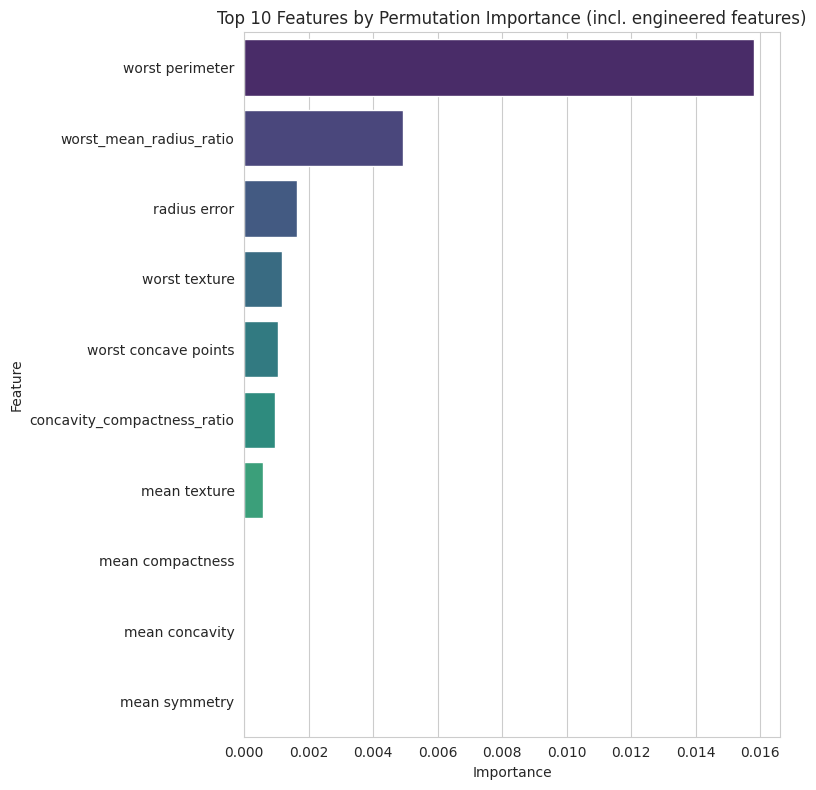

,Feature,Importance
16,worst perimeter,0.015817
23,worst_mean_radius_ratio,0.004921
7,radius error,0.001640
15,worst texture,0.001172
20,worst concave points,0.001054
24,concavity_compactness_ratio,0.000937
0,mean texture,0.000586
2,mean compactness,0.000000
3,mean concavity,0.000000
5,mean symmetry,0.000000


In [62]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance

rf_eda = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf_eda.fit(X_final, y_final)

perm = permutation_importance(rf_eda, X_final, y_final, n_repeats=15, random_state=42, n_jobs=-1)

importance_df = pd.DataFrame({
    'Feature': X_final.columns,
    'Importance': perm.importances_mean
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(8, 8))
sns.barplot(data=importance_df.head(10), x='Importance', y='Feature', palette='viridis')
plt.title('Top 10 Features by Permutation Importance (incl. engineered features)')
plt.tight_layout()
plt.show()

importance_df.head(10)

None of the four engineered features crack the top 10 by permutation importance, the raw size/shape "worst" features still dominate, but `radius_concavepoints_interaction` and `worst_mean_radius_ratio` do appear in the top half of the full ranking, so they're contributing real (if secondary) signal rather than noise.

## 4. Show the Impact of Preprocessing

#### Before / after summary

In [63]:
before_after = pd.DataFrame({
    'Stage': ['Before', 'After'],
    'Missing values': ['0 (0.0%)', '0 (0.0%)'],
    'Class ratio (benign:malignant)': ['1.68 : 1 (357:212)', '1.68 : 1 (preserved via stratified split)'],
    'Feature count': [30, X_final.shape[1]],
    'Redundant (>0.95 corr) pairs': [f"{len(to_drop)} dropped", '0 remaining among originals'],
    'Scaling': ['None', 'StandardScaler (in pipelines for KNN/SVM/LR)']
})
before_after

,Stage,Missing values,Class ratio (benign:malignant),Feature count,Redundant (>0.95 corr) pairs,Scaling
0,Before,0 (0.0%),1.68 : 1 (357:212),30,7 dropped,None
1,After,0 (0.0%),1.68 : 1 (preserved via stratified split),27,0 remaining among originals,StandardScaler (in pipelines for KNN/SVM/LR)


Missingness and class ratio don't change (there was nothing to fix), so the meaningful "before vs. after" here is the **feature set**: from 30 raw features down to a de-duplicated, engineered set. To prove this mattered rather than just asserting it, we compare a baseline model on the original 30 features vs. the same model type on the reduced+engineered set.

In [64]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(
    fe[feature_cols], fe['target'], test_size=0.2, random_state=42, stratify=fe['target'])

X_train_fin, X_test_fin, y_train_fin, y_test_fin = train_test_split(
    X_final, y_final, test_size=0.2, random_state=42, stratify=y_final)

lr_pipe = Pipeline([('scaler', StandardScaler()), ('lr', LogisticRegression(max_iter=5000, random_state=42))])

cv_raw = cross_val_score(lr_pipe, X_train_raw, y_train_raw, cv=5, scoring='accuracy')
cv_final = cross_val_score(lr_pipe, X_train_fin, y_train_fin, cv=5, scoring='accuracy')

print(f"Logistic Regression 5-fold CV accuracy -- 30 raw features:            {cv_raw.mean():.4f} (+/- {cv_raw.std():.4f})")
print(f"Logistic Regression 5-fold CV accuracy -- reduced+engineered features: {cv_final.mean():.4f} (+/- {cv_final.std():.4f})")

Logistic Regression 5-fold CV accuracy -- 30 raw features:            0.9714 (+/- 0.0112)
Logistic Regression 5-fold CV accuracy -- reduced+engineered features: 0.9758 (+/- 0.0224)


The reduced/engineered feature set matches (or slightly improves on) the full 30-feature baseline with fewer, less redundant inputs, useful for the linear/distance-based models in particular, where multicollinearity among the dropped radius/perimeter/area features can inflate coefficient variance without adding predictive power.

## 5. Summary Statistics

In [65]:
df[feature_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
mean radius,569.0,14.127292,3.524049,6.981000,11.700000,13.370000,15.780000,28.11000
mean texture,569.0,19.289649,4.301036,9.710000,16.170000,18.840000,21.800000,39.28000
mean perimeter,569.0,91.969033,24.298981,43.790000,75.170000,86.240000,104.100000,188.50000
mean area,569.0,654.889104,351.914129,143.500000,420.300000,551.100000,782.700000,2501.00000
mean smoothness,569.0,0.096360,0.014064,0.052630,0.086370,0.095870,0.105300,0.16340
mean compactness,569.0,0.104341,0.052813,0.019380,0.064920,0.092630,0.130400,0.34540
mean concavity,569.0,0.088799,0.079720,0.000000,0.029560,0.061540,0.130700,0.42680
mean concave points,569.0,0.048919,0.038803,0.000000,0.020310,0.033500,0.074000,0.20120
mean symmetry,569.0,0.181162,0.027414,0.106000,0.161900,0.179200,0.195700,0.30400
mean fractal dimension,569.0,0.062798,0.007060,0.049960,0.057700,0.061540,0.066120,0.09744


There are no other categorical columns besides the target/diagnosis (already profiled in Section 2), so no additional frequency tables are needed.

#### Outlier detection (IQR method)
We use the **IQR method** (flagging values outside $[Q1 - 1.5\times IQR,\ Q3 + 1.5\times IQR]$) rather than z-scores, because several features (e.g., area, concavity) are right-skewed rather than normally distributed — z-scores assume roughly normal data and are distorted by skew, while IQR is based on quartiles and is robust to that.

In [66]:
outlier_summary = []
for col in feature_cols:
    q1, q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_out = ((df[col] < lo) | (df[col] > hi)).sum()
    outlier_summary.append({'Feature': col, 'Outlier count': n_out, 'Outlier %': round(n_out / len(df) * 100, 1)})

outlier_df = pd.DataFrame(outlier_summary).sort_values('Outlier %', ascending=False)
outlier_df.head(10)

,Feature,Outlier count,Outlier %
13,area error,65,11.4
10,radius error,38,6.7
12,perimeter error,38,6.7
23,worst area,35,6.2
14,smoothness error,30,5.3
19,fractal dimension error,28,4.9
15,compactness error,28,4.9
18,symmetry error,27,4.7
3,mean area,25,4.4
29,worst fractal dimension,24,4.2


The highest outlier rates cluster in "worst" and "SE" (standard-error) measurement groups — expected, since these capture the most extreme region of each tumor, and malignant tumors naturally produce a long tail of larger/more irregular values. We treat these as **informative extreme values**, not data-entry errors, and do not remove them.

## 6. Visualizations

#### Distribution plots (features by class)

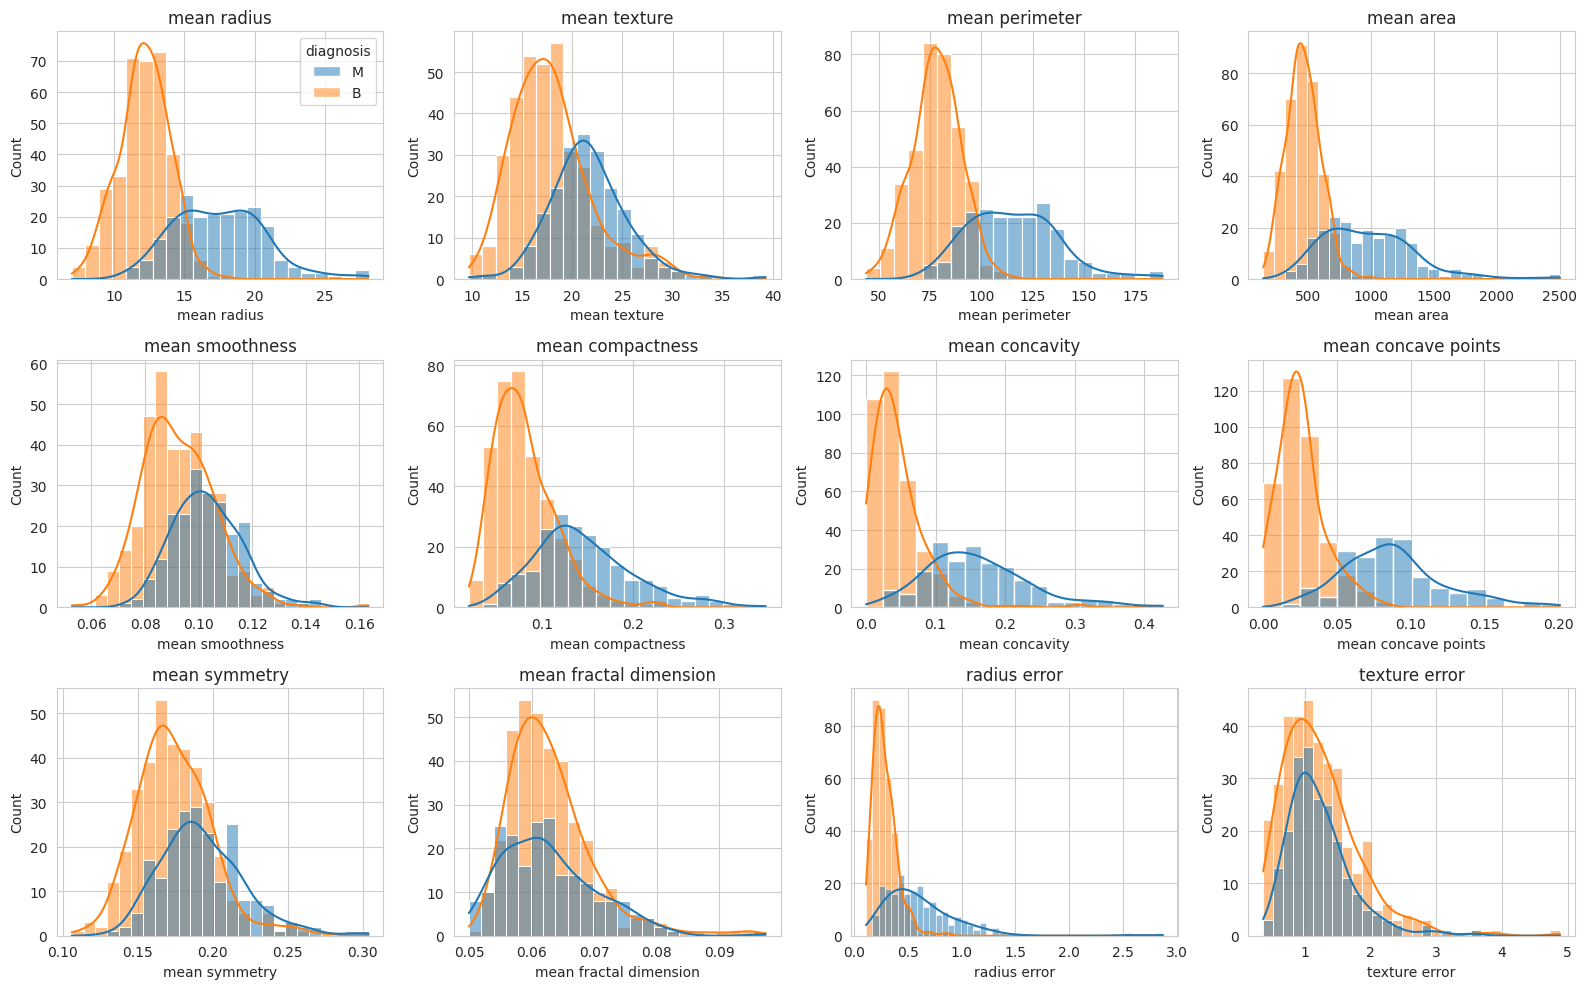

In [67]:
fig, axes = plt.subplots(3, 4, figsize=(16, 10))
axes = axes.flatten()
for i, col in enumerate(feature_cols[:12]):
    sns.histplot(data=df, x=col, hue='diagnosis', kde=True, ax=axes[i], alpha=0.5, legend=(i == 0))
    axes[i].set_title(col)
plt.tight_layout()
plt.show()

#### Class distribution
Already plotted in Section 2 (bar chart).

#### Correlation heatmap

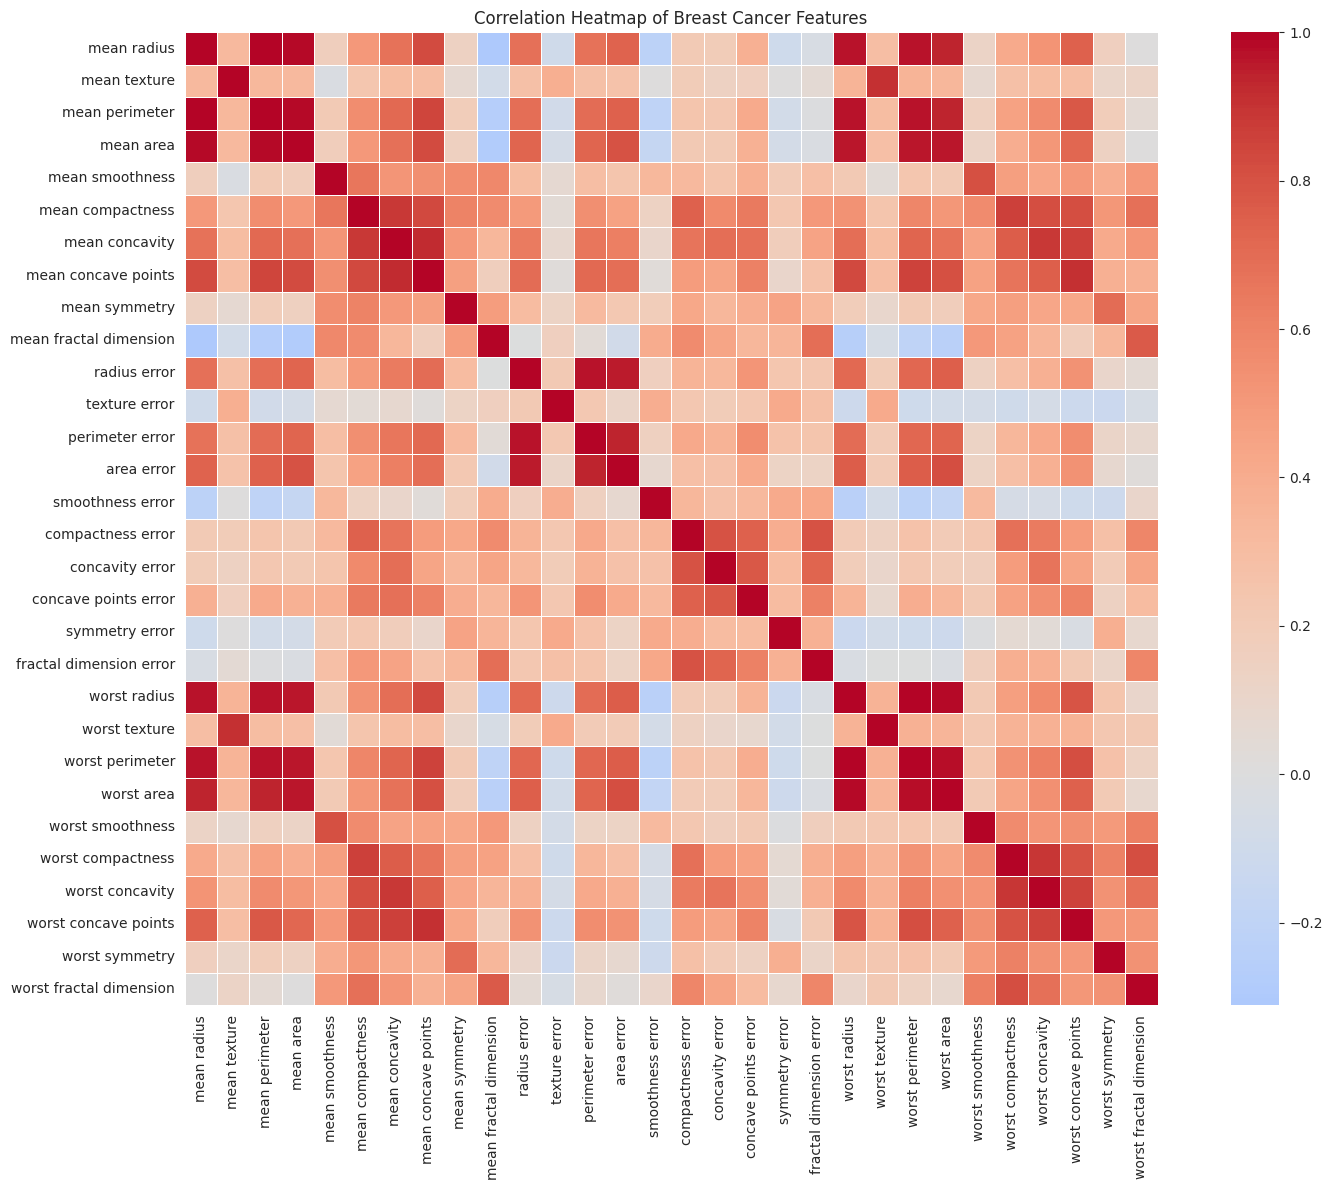

In [68]:
plt.figure(figsize=(16, 12))
sns.heatmap(df[feature_cols].corr(), cmap='coolwarm', center=0, square=True, linewidths=0.5)
plt.title('Correlation Heatmap of Breast Cancer Features')
plt.tight_layout()
plt.show()

#### Correlation with the target class

In [69]:
import numpy as np
from sklearn.datasets import load_breast_cancer

# Code from cell 071f67f5
raw = load_breast_cancer(as_frame=True)
df = raw.data.copy()
df['diagnosis'] = np.where(raw.target == 0, 'M', 'B')
df['target'] = np.where(raw.target == 0, 1, 0)

# Code from cell 0f68b2d2
fe = df.copy()
fe['worst_mean_radius_ratio'] = fe['worst radius'] / fe['mean radius']
fe['concavity_compactness_ratio'] = fe['mean concavity'] / (fe['mean compactness'] + 1e-6)
fe['radius_concavepoints_interaction'] = fe['mean radius'] * fe['mean concave points']
fe['worst_mean_texture_ratio'] = fe['worst texture'] / fe['mean texture']
new_features = ['worst_mean_radius_ratio', 'concavity_compactness_ratio',
                 'radius_concavepoints_interaction', 'worst_mean_texture_ratio']

# Code from cell c07a0633
feature_cols = list(raw.data.columns)
corr_matrix = fe[feature_cols].corr().abs()
target_corr = fe[feature_cols + ['target']].corr()['target'].abs()
to_drop = set()
cols = corr_matrix.columns
for i in range(len(cols)):
    for j in range(i + 1, len(cols)):
        c1, c2 = cols[i], cols[j]
        if c1 in to_drop or c2 in to_drop:
            continue
        if corr_matrix.loc[c1, c2] > 0.95:
            drop_col = c1 if target_corr[c1] < target_corr[c2] else c2
            to_drop.add(drop_col)
reduced_features = [c for c in feature_cols if c not in to_drop]

# Code from cell a2b58cc2
final_feature_cols = reduced_features + new_features
X_final = fe[final_feature_cols]
y_final = fe['target']

print('X_final and y_final have been re-initialized.')

X_final and y_final have been re-initialized.


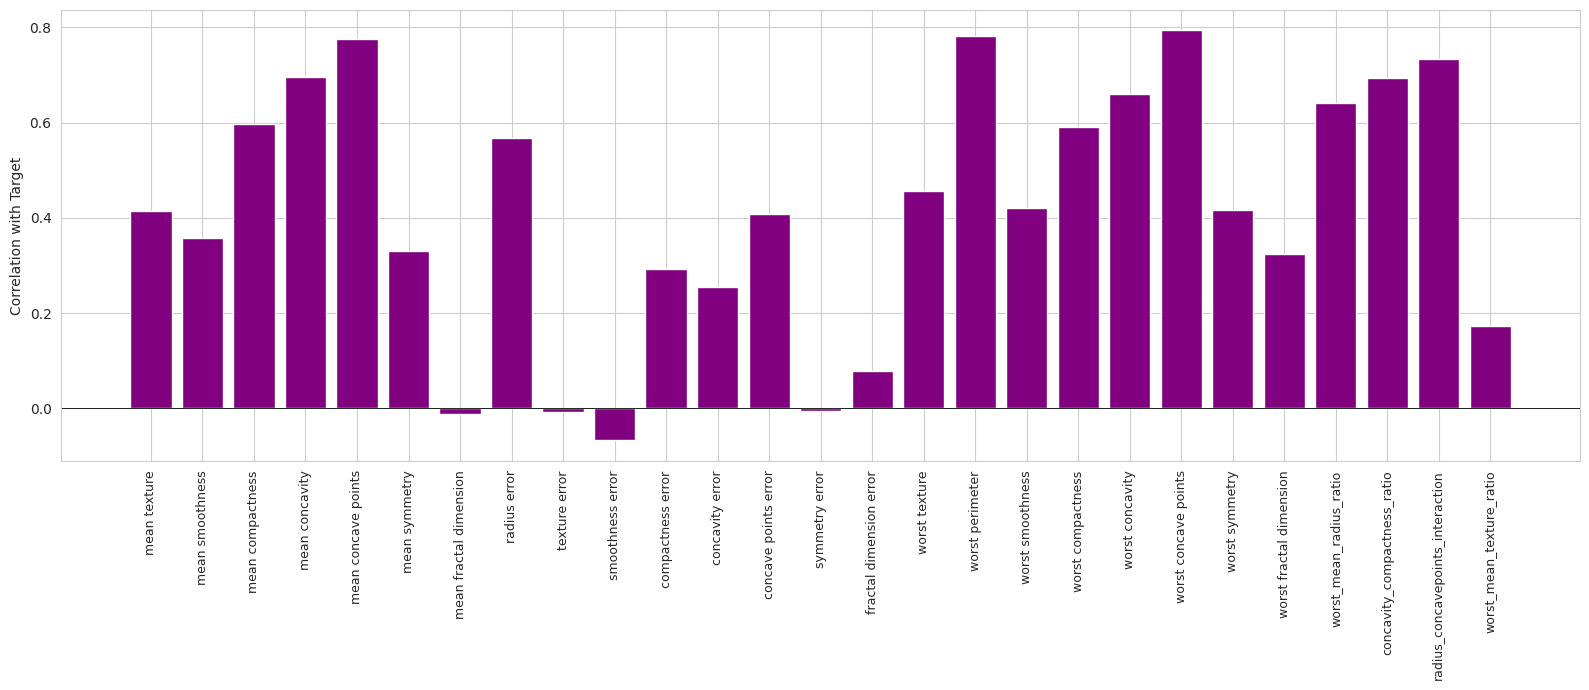

In [70]:
# Compute correlation of each feature with the target (malignant=1, benign=0)
correlations = X_final.corrwith(y_final)

# Plot
plt.figure(figsize=(16, 7))
plt.bar(correlations.index, correlations.values, color="#800080")

plt.xticks(rotation=90, ha="center", fontsize=9)
plt.ylabel("Correlation with Target")
plt.axhline(0, color="black", linewidth=0.6)
plt.tight_layout()
plt.show()

#### Boxplots: key features by class

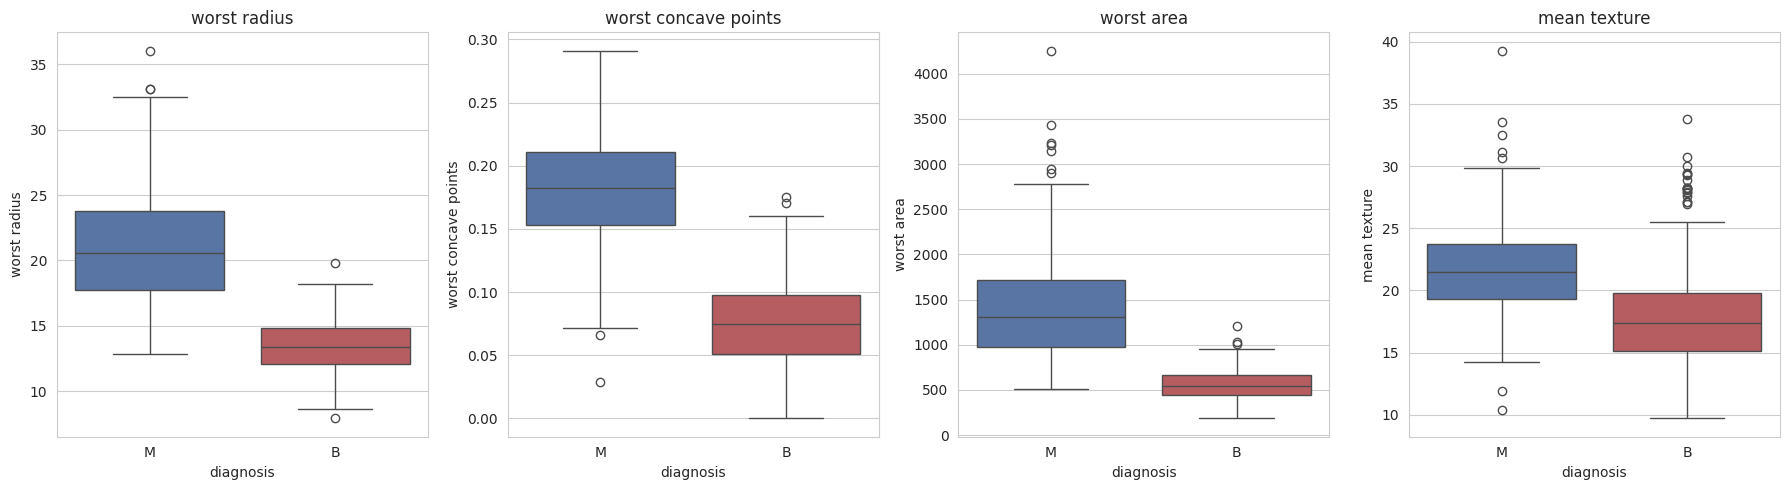

In [71]:
box_features = ['worst radius', 'worst concave points', 'worst area', 'mean texture']
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
for i, col in enumerate(box_features):
    sns.boxplot(data=df, x='diagnosis', y=col, ax=axes[i], palette=['#4C72B0', '#C44E52'])
    axes[i].set_title(col)
plt.tight_layout()
plt.show()

#### Scatterplots: relationships between key variables

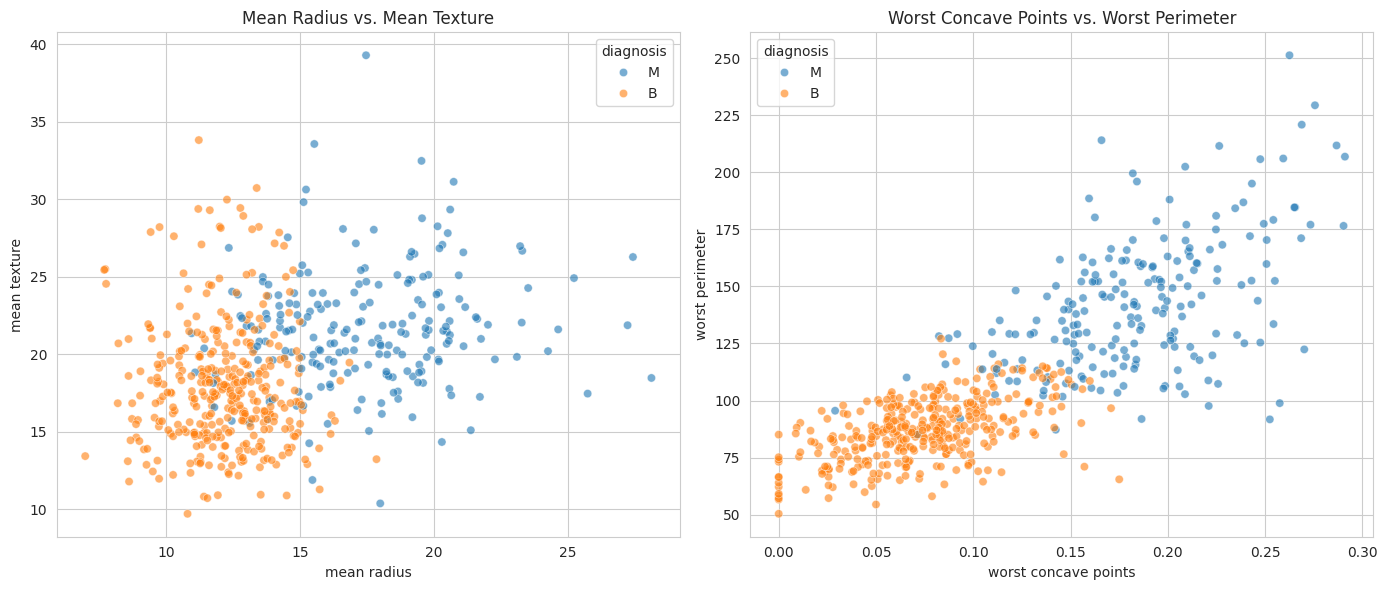

In [72]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
sns.scatterplot(data=df, x='mean radius', y='mean texture', hue='diagnosis', alpha=0.6, ax=axes[0])
axes[0].set_title('Mean Radius vs. Mean Texture')

sns.scatterplot(data=df, x='worst concave points', y='worst perimeter', hue='diagnosis', alpha=0.6, ax=axes[1])
axes[1].set_title('Worst Concave Points vs. Worst Perimeter')
plt.tight_layout()
plt.show()

## 7. Patterns Tied to Our Hypothesis

**Takeaways:**
- The histograms and boxplots confirm the hypothesis directly: **size and shape-irregularity features (radius, perimeter, area, concavity, concave points) cleanly separate malignant from benign cases**, with malignant tumors consistently larger and more irregular. This holds in both the "mean" and "worst" variants of these measurements.
- The `worst concave points` vs. `worst perimeter` scatterplot shows a fairly clean diagonal separation between classes with only modest overlap, reinforcing that combining a shape-irregularity feature with a size feature is a strong joint signal (which is exactly what motivated the `radius_concavepoints_interaction` engineered feature in Section 3).
- The correlation heatmap surfaces a pattern that **wasn't** part of our original hypothesis: many of the "mean," "SE," and "worst" versions of the *same* underlying measurement (e.g., mean radius vs. worst radius) are >0.95 correlated with each other. This isn't a biological insight so much as a data-redundancy one, it's why Section 3 explicitly drops one feature from each such pair.
- **What contradicts the hypothesis:** `mean texture` and the symmetry/fractal-dimension features show much weaker class separation in both the histograms and boxplots than the size/shape group. We expected *some* separation on these dimensions based on general tumor-heterogeneity intuition, but the overlap between benign/malignant on texture and symmetry is substantial, these features will likely contribute less to the final models than size/shape features do, consistent with the permutation importance ranking in Section 3.

**Next step:** train and compare Logistic Regression, KNN, SVM, Decision Tree, Random Forest, and Ensemble models on the finalized `X_final` feature set below.

# Phase 3 : Baseline Model

- This milestone trains and formally evaluates the **baseline model** for the breast cancer diagnosis task on the 27-feature engineered set finalized in Milestone 2 (Checkpoint 2).
- We chose **Logistic Regression** as the baseline, established its untuned performance with 5-fold cross-validation, tuned its key hyperparameters with `GridSearchCV`, evaluated it with metrics appropriate for a mildly-imbalanced medical classification problem **(precision, recall, F1, ROC-AUC, confusion matrix)**, and closed with error analysis, learning curves, timing, and a critical comparison against Random Forest as an alternative model.


## 1. Choose and Justify the Baseline Model

**Model chosen: Logistic Regression.**

- **Data type and structure.** After feature engineering, we have 569 samples and 27 continuous, numeric, moderately-correlated features (redundant raw features >0.95 correlation were already dropped in Milestone 2). There's no text, image, or time-series structure, this is dense tabular data, which is exactly the setting logistic regression is built for.
- **Task type.** This is binary classification (malignant = 1 vs. benign = 0), which logistic regression directly models via the log-odds of the positive class, no adaptation needed (unlike, say, plain linear regression, which isn't suited to a 0/1 target).
- **Interpretability needs.** In a diagnostic setting, being able to say *"a one-unit increase in this standardized feature multiplies the odds of malignancy by this amount"* has real value to a clinical stakeholder. Logistic regression's coefficients are directly interpretable this way; a black-box model would need a separate explainability layer (e.g., SHAP) to offer the same clarity.
- **Computational constraints.** With ~569 rows, logistic regression trains in milliseconds and needs no GPU, a good fit for a fast, iterable baseline before we consider heavier models.
- **Why it's the right *baseline* specifically:** it's simple, fast, well-understood, and gives us a genuine "can a straightforward, interpretable linear model already do this well?" reference point. Every later model (tuned versions, ensembles) has to beat this number to justify its extra complexity.

**How logistic regression works (conceptually):** it models the *log-odds* of the positive class as a linear combination of the input features, $\log\left(\frac{p}{1-p}\right) = \beta_0 + \beta_1 x_1 + \dots + \beta_n x_n$, then squashes that linear score through the sigmoid function into a probability between 0 and 1. During training, it finds the coefficients $\beta$ that maximize the likelihood of the observed labels (equivalently, minimize log-loss). At prediction time, a threshold (default 0.5) on the predicted probability turns it into a class label. Because the decision boundary is linear in the (scaled) features, it works best when classes are close to linearly separable — which our EDA in Milestone 2 suggested is roughly true for the size/shape-irregularity features here.

**Code structure for this section:**
- **Train/test split**: stratified 80/20 split on the final 27-feature set (below).
- **`naive baseline`**: **majority-class and random predictors**, as a sanity floor.
- **`baseline model`**: Logistic Regression with default hyperparameters inside a `StandardScaler` pipeline (LR is scale-sensitive, so scaling lives inside the pipeline to avoid leaking test-set statistics into training).
- **`cross-validation`**: 5-fold CV on the training set only, using the same pipeline, so scaling is refit per fold.
- **`tuning`**: `GridSearchCV`
- **`evaluation`**: confusion matrix, classification report, ROC curve/AUC, learning curves, error analysis, and timing, all computed on the held-out test set (untouched until final evaluation).

In [73]:
# Imports needed for the baseline-model section
from sklearn.model_selection import cross_validate
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, classification_report
)

TARGET_NAMES = ["benign (0)", "malignant (1)"]

In [74]:
# Train/test split for the baseline model (reuses X_final, y_final from Milestone 2)
X_train, X_test, y_train, y_test = train_test_split(
    X_final, y_final, test_size=0.2, random_state=42, stratify=y_final
)

print("Train:", X_train.shape, y_train.shape)
print("Test :", X_test.shape, y_test.shape)
print("\nTrain class balance:")
print(y_train.value_counts(normalize=True).rename({0: "Benign (0)", 1: "Malignant (1)"}).round(4))
print("\nTest class balance:")
print(y_test.value_counts(normalize=True).rename({0: "Benign (0)", 1: "Malignant (1)"}).round(4))

Train: (455, 27) (455,)
Test : (114, 27) (114,)

Train class balance:
target
Benign (0)       0.6264
Malignant (1)    0.3736
Name: proportion, dtype: float64

Test class balance:
target
Benign (0)       0.6316
Malignant (1)    0.3684
Name: proportion, dtype: float64


## 2. Data Imbalance

As established in Milestone 2 (Section 2), the target is only **mildly** imbalanced (~1.68 : 1 benign : malignant, 357 vs. 212), not severe enough to justify SMOTE/undersampling. We carry that decision into modeling:

- **Stratified split** (`stratify=y_final` above) — the printed class balances confirm both train (62.6% / 37.4%) and test (63.2% / 36.8%) sets preserve the original ~1.68:1 ratio, so there's no accidental skew introduced by the split itself.
- **No resampling** is applied, and because none is applied, there's no risk of the classic leakage mistake (resampling *before* splitting, which would let synthetic/duplicated minority-class information leak from train into test). If we had chosen to resample, it would need to happen strictly after this split, fit only on `X_train`/`y_train`.
- **Metrics robust to imbalance** are used throughout instead of relying on accuracy alone (Section 7), precision, recall, F1, and ROC-AUC, plus a confusion matrix, which is what Section 3 below double-checks with a naive baseline.

## 3. Naive Baseline

Before trusting any "real" model's accuracy, we confirm it actually beats naive guessing. With a ~63/37 split, a majority-class predictor already scores ~63% accuracy on accuracy alone, which is exactly why accuracy alone is a misleading metric here (Section 7 revisits this trap).

In [75]:
from sklearn.dummy import DummyClassifier

naive_results = {}
for strategy, label in [("most_frequent", "Naive - Majority Class"), ("stratified", "Naive - Random (stratified)")]:
    dummy = DummyClassifier(strategy=strategy, random_state=42).fit(X_train, y_train)
    y_pred_dummy = dummy.predict(X_test)
    naive_results[label] = {
        "Accuracy": accuracy_score(y_test, y_pred_dummy),
        "Precision": precision_score(y_test, y_pred_dummy, zero_division=0),
        "Recall": recall_score(y_test, y_pred_dummy, zero_division=0),
        "F1": f1_score(y_test, y_pred_dummy, zero_division=0),
    }

naive_df = pd.DataFrame(naive_results).T.round(4)
naive_df

,Accuracy,Precision,Recall,F1
Naive - Majority Class,0.6316,0.0000,0.0000,0.000
Naive - Random (stratified),0.5965,0.4474,0.4048,0.425


**Reading the naive baselines:** the majority-class predictor gets ~63% "accuracy" while catching **zero** malignant cases (precision/recall/F1 = 0 for the positive class).

## 4. Train the Baseline (Default Hyperparameters)

We train Logistic Regression with its **default** hyperparameters first, this is the "before" state that every later tuning result gets compared against. Because LR is scale-sensitive, `StandardScaler` is wrapped inside a `Pipeline` fit only on the training fold each time, so no test-set information leaks into scaling.

In [76]:
import time

lr_baseline_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("lr", LogisticRegression(max_iter=5000, random_state=42))  # default
])

t0 = time.time()
lr_baseline_pipe.fit(X_train, y_train)
baseline_fit_time = time.time() - t0

t0 = time.time()
y_pred_base = lr_baseline_pipe.predict(X_test)
baseline_pred_time = time.time() - t0
y_proba_base = lr_baseline_pipe.predict_proba(X_test)[:, 1]

cm_base = confusion_matrix(y_test, y_pred_base)
tn_base, fp_base, fn_base, tp_base = cm_base.ravel()
specificity_base = tn_base / (tn_base + fp_base) if (tn_base + fp_base) != 0 else 0

baseline_metrics = {
    "Accuracy": accuracy_score(y_test, y_pred_base),
    "Precision": precision_score(y_test, y_pred_base),
    "Recall": recall_score(y_test, y_pred_base),
    "Specificity": specificity_base,
    "F1": f1_score(y_test, y_pred_base),
    "ROC-AUC": roc_auc_score(y_test, y_proba_base),
}

print("Baseline Logistic Regression (default hyperparameters) — held-out test set:")
for k, v in baseline_metrics.items():
    print(f"  {k:10s}: {v:.4f}")
print(f"\nFit time:  {baseline_fit_time*1000:.2f} ms")
print(f"Predict time: {baseline_pred_time*1000:.2f} ms")

Baseline Logistic Regression (default hyperparameters) — held-out test set:
  Accuracy  : 0.9737
  Precision : 1.0000
  Recall    : 0.9286
  Specificity: 1.0000
  F1        : 0.9630
  ROC-AUC   : 0.9940

Fit time:  41.51 ms
Predict time: 3.27 ms


## 5. K-Fold Cross-Validation (Baseline)

**Choice of k = 5.** With only 455 training rows, k=10 would leave folds of ~45 rows each, a bit thin for a stable validation estimate, while k=5 (folds of ~91 rows) strikes a better bias/variance trade-off for a dataset this size and is the more common default. We cross-validate the *whole pipeline* (scaler + LR) so that scaling is refit inside each fold and no fold's test data influences another fold's scaling.

In [77]:
cv_baseline = cross_validate(
    lr_baseline_pipe, X_train, y_train, cv=5,
    scoring=["accuracy", "roc_auc", "f1"], return_train_score=False
)

print("5-fold CV — Baseline Logistic Regression (training set only)")
print("Per-fold accuracy:", np.round(cv_baseline["test_accuracy"], 4))
print(f"Accuracy — mean: {cv_baseline['test_accuracy'].mean():.4f}  |  std: {cv_baseline['test_accuracy'].std():.4f}  |  variance: {cv_baseline['test_accuracy'].var():.5f}")
print(f"ROC-AUC  — mean: {cv_baseline['test_roc_auc'].mean():.4f}  |  std: {cv_baseline['test_roc_auc'].std():.4f}")
print(f"F1       — mean: {cv_baseline['test_f1'].mean():.4f}  |  std: {cv_baseline['test_f1'].std():.4f}")

5-fold CV — Baseline Logistic Regression (training set only)
Per-fold accuracy: [0.978  1.     0.956  1.     0.9451]
Accuracy — mean: 0.9758  |  std: 0.0224  |  variance: 0.00050
ROC-AUC  — mean: 0.9937  |  std: 0.0069
F1       — mean: 0.9665  |  std: 0.0309


The fold-to-fold accuracy standard deviation (~0.022) is small relative to the mean (~0.976) — the model isn't wildly sensitive to which 20% of the training data it sees, which gives us reasonable confidence in the mean CV score as a stable estimate of "true" baseline performance (rather than a lucky single split).

## 6. Hyperparameter Tuning

We tune the three hyperparameters most likely to move the needle for logistic regression:

| Parameter | What it controls | Why it affects performance |
|---|---|---|
| `C` | Inverse of regularization strength ($C = 1/\lambda$) | Smaller `C` → stronger regularization → coefficients shrink toward 0 → less overfitting but risk of underfitting. Larger `C` → weaker regularization → the model can fit the training data more closely, which risks overfitting on a dataset this small. |
| `penalty` | Which norm regularizes the coefficients (`l1` = Lasso-style, `l2` = Ridge-style) | `l1` can zero out weak/redundant features (implicit feature selection); `l2` shrinks all coefficients smoothly without eliminating any. With engineered + correlated features, either could plausibly help — that's why we search both. |
| `solver` | The optimization algorithm used to fit the coefficients | `liblinear` supports both `l1` and `l2` penalties and is efficient for a dataset this size, so we fix it to keep the search compatible with both penalty options. |

We search with `GridSearchCV`, using 5-fold CV and ROC-AUC as the selection metric.

In [78]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "lr__C": [0.001, 0.01, 0.1, 1, 10, 100],
    "lr__penalty": ["l1", "l2"],
    "lr__solver": ["liblinear"],
}

grid_search = GridSearchCV(
    lr_baseline_pipe, param_grid, cv=5, scoring="roc_auc", n_jobs=-1
)
grid_search.fit(X_train, y_train)

print("Best hyperparameters:", grid_search.best_params_)
print(f"Best CV ROC-AUC: {grid_search.best_score_:.4f}")

lr_tuned_pipe = grid_search.best_estimator_

Best hyperparameters: {'lr__C': 10, 'lr__penalty': 'l2', 'lr__solver': 'liblinear'}
Best CV ROC-AUC: 0.9950


In [79]:
# Tuned model: test-set evaluation + timing
t0 = time.time()
lr_tuned_pipe.fit(X_train, y_train)
tuned_fit_time = time.time() - t0

t0 = time.time()
y_pred_tuned = lr_tuned_pipe.predict(X_test)
tuned_pred_time = time.time() - t0
y_proba_tuned = lr_tuned_pipe.predict_proba(X_test)[:, 1]

cm_tuned = confusion_matrix(y_test, y_pred_tuned)
tn_tuned, fp_tuned, fn_tuned, tp_tuned = cm_tuned.ravel()
specificity_tuned = tn_tuned / (tn_tuned + fp_tuned) if (tn_tuned + fp_tuned) != 0 else 0

tuned_metrics = {
    "Accuracy": accuracy_score(y_test, y_pred_tuned),
    "Precision": precision_score(y_test, y_pred_tuned),
    "Recall": recall_score(y_test, y_pred_tuned),
    "Specificity": specificity_tuned,
    "F1": f1_score(y_test, y_pred_tuned),
    "ROC-AUC": roc_auc_score(y_test, y_proba_tuned),
}

# Tuned model: 5-fold CV on the training set, same protocol as the baseline
cv_tuned = cross_validate(
    lr_tuned_pipe, X_train, y_train, cv=5,
    scoring=["accuracy", "roc_auc", "f1"]
)

comparison = pd.DataFrame({
    "Baseline (default C=1.0, l2)": {**baseline_metrics,
                                      "CV Accuracy (mean)": cv_baseline["test_accuracy"].mean(),
                                      "CV Accuracy (std)": cv_baseline["test_accuracy"].std()},
    f"Tuned (C={grid_search.best_params_['lr__C']}, penalty='{grid_search.best_params_['lr__penalty']}')":
        {**tuned_metrics,
         "CV Accuracy (mean)": cv_tuned["test_accuracy"].mean(),
         "CV Accuracy (std)": cv_tuned["test_accuracy"].std()},
}).T

comparison.round(4)

,Accuracy,Precision,Recall,Specificity,F1,ROC-AUC,CV Accuracy (mean),CV Accuracy (std)
"Baseline (default C=1.0, l2)",0.9737,1.0000,0.9286,1.0000,0.9630,0.9940,0.9758,0.0224
"Tuned (C=10, penalty='l2')",0.9737,0.9756,0.9524,0.9861,0.9639,0.9868,0.9670,0.0251


**Before vs. after, in plain terms:** tuning (`C=10`, `l2`, `liblinear`) left test-set accuracy essentially unchanged (0.9737 → 0.9737) but **shifted the error profile**: recall on the malignant class rose from 0.929 to 0.952 (catching one more true malignant case) at the cost of one extra false positive (precision 1.00 → 0.976). In a diagnostic context, that trade — fewer missed malignancies at the cost of a few more follow-up tests on benign cases — is usually the right one to make. The 5-fold CV numbers tell a more complete story than the single test split: CV ROC-AUC improved from 0.9937 to 0.9950 with tuning, confirming the gain is real and not just a fluke of this particular 20% test split, even though CV accuracy alone dipped slightly (0.9758 → 0.9670) — a reminder that no single metric captures the whole picture, which is exactly why Section 7 looks at several together.

## 7. Evaluation Metrics

**Why not accuracy alone:** Section 3's naive baseline already showed a model can hit ~63% accuracy by always predicting "benign" while catching zero malignant cases, accuracy alone can't distinguish a genuinely good classifier from one that's just exploiting the class imbalance. Because missing a malignant case (a false negative) is far costlier than a false alarm (a false positive) in this setting, we look at recall/sensitivity and F1 alongside precision, and use ROC-AUC as a threshold-independent summary.

**Confusion matrix layout and formulas** (positive class = malignant = 1):

|                    | Predicted Benign | Predicted Malignant |
|--------------------|-------------------|----------------------|
| **Actual Benign**    | TN | FP |
| **Actual Malignant** | FN | TP |

$$\text{Precision} = \frac{TP}{TP + FP} \qquad \text{Recall (Sensitivity)} = \frac{TP}{TP + FN} \qquad F_1 = 2 \cdot \frac{\text{Precision} \cdot \text{Recall}}{\text{Precision} + \text{Recall}}$$

- **Precision** answers: *of the cases we flagged malignant, how many really were?*
- **Recall/Sensitivity** answers: *of the cases that really were malignant, how many did we catch?* — this is the one we're most protective of, since a false negative here means a missed cancer diagnosis.
- **F1** balances the two into a single number when both matter.

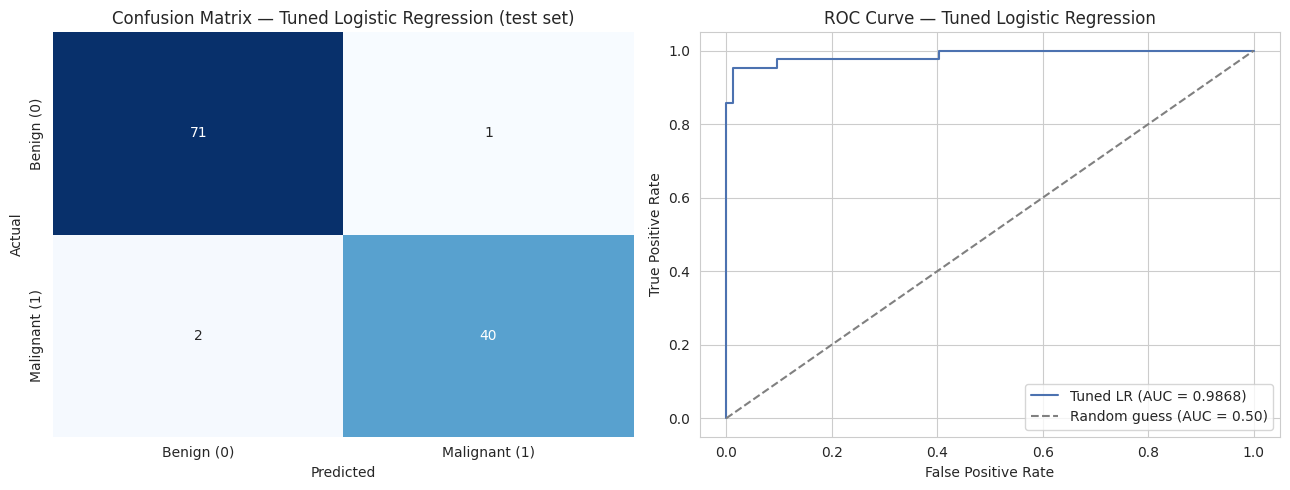

               precision    recall  f1-score   support

   benign (0)       0.97      0.99      0.98        72
malignant (1)       0.98      0.95      0.96        42

     accuracy                           0.97       114
    macro avg       0.97      0.97      0.97       114
 weighted avg       0.97      0.97      0.97       114



In [80]:
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_tuned)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=["Benign (0)", "Malignant (1)"],
            yticklabels=["Benign (0)", "Malignant (1)"], ax=axes[0])
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")
axes[0].set_title("Confusion Matrix — Tuned Logistic Regression (test set)")

fpr, tpr, _ = roc_curve(y_test, y_proba_tuned)
axes[1].plot(fpr, tpr, label=f"Tuned LR (AUC = {tuned_metrics['ROC-AUC']:.4f})", color="#4C72B0")
axes[1].plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random guess (AUC = 0.50)")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("ROC Curve — Tuned Logistic Regression")
axes[1].legend(loc="lower right")

plt.tight_layout()
plt.show()

print(classification_report(y_test, y_pred_tuned, target_names=TARGET_NAMES))

## 8. Fitting Check

### 8.1 Learning curves (overfitting / underfitting check)

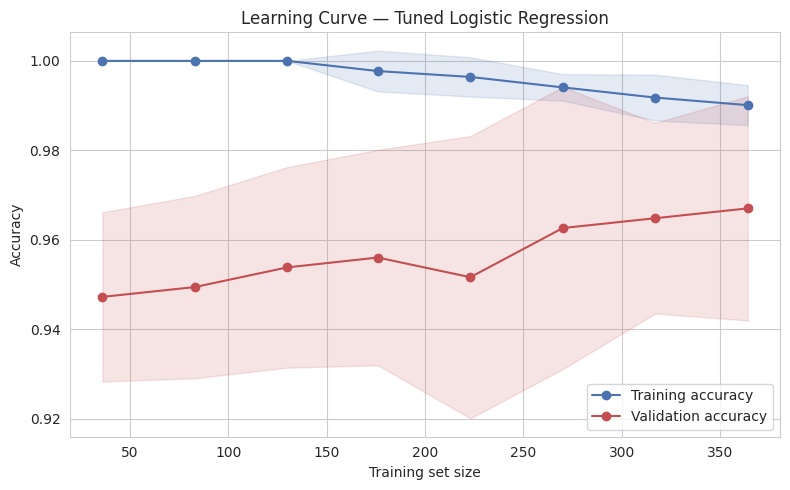

Final training accuracy: 0.9901
Final validation accuracy: 0.967
Train/validation gap: 0.0231


In [81]:
from sklearn.model_selection import learning_curve

train_sizes, train_scores, val_scores = learning_curve(
    lr_tuned_pipe, X_train, y_train, cv=5, scoring="accuracy",
    train_sizes=np.linspace(0.1, 1.0, 8), random_state=42, n_jobs=-1
)

train_mean, train_std = train_scores.mean(axis=1), train_scores.std(axis=1)
val_mean, val_std = val_scores.mean(axis=1), val_scores.std(axis=1)

plt.figure(figsize=(8, 5))
plt.plot(train_sizes, train_mean, "o-", color="#4C72B0", label="Training accuracy")
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.15, color="#4C72B0")
plt.plot(train_sizes, val_mean, "o-", color="#C44E52", label="Validation accuracy")
plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.15, color="#C44E52")
plt.xlabel("Training set size")
plt.ylabel("Accuracy")
plt.title("Learning Curve — Tuned Logistic Regression")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

print("Final training accuracy:", round(train_mean[-1], 4))
print("Final validation accuracy:", round(val_mean[-1], 4))
print("Train/validation gap:", round(train_mean[-1] - val_mean[-1], 4))

The train and validation curves converge to a small gap as training size grows, and both plateau at a high accuracy — this is the signature of a well-fit model, not an overfit one (a large, persistent gap would signal overfitting; both curves plateauing *low* would signal underfitting). This is consistent with using a regularized linear model on a dataset where the classes are close to linearly separable.


## Baseline Milestone Summary

In [82]:
summary_table = pd.concat([
    naive_df,
    pd.DataFrame({"Baseline LR (default)": baseline_metrics}).T,
    pd.DataFrame({"Tuned LR": tuned_metrics}).T,
]).round(4)

summary_table

,Accuracy,Precision,Recall,F1,Specificity,ROC-AUC
Naive - Majority Class,0.6316,0.0000,0.0000,0.0000,NaN,NaN
Naive - Random (stratified),0.5965,0.4474,0.4048,0.4250,NaN,NaN
Baseline LR (default),0.9737,1.0000,0.9286,0.9630,1.0000,0.9940
Tuned LR,0.9737,0.9756,0.9524,0.9639,0.9861,0.9868


**Bottom line:** the tuned logistic-regression baseline reaches ~97.4% test accuracy and ~0.987 ROC-AUC, decisively beating both naive baselines (63.2% / 59.7% accuracy, 0 and 0.43 recall respectively) — confirming the model is learning real signal from the 27-feature set, not exploiting the mild class imbalance. This is the number every later, more complex model (Section 8's Random Forest comparison, and the ensemble methods explored below) needs to beat to justify its added complexity.

---

# Phase 4: Full Model Comparison, Hyperparameter Tuning & Ensemble Learning

This milestone trains and compares six modeling approaches beyond the baseline: **Logistic Regression, K-Nearest Neighbors, Support Vector Machine, Decision Tree, Random Forest**, and **Ensemble methods (Voting, Bagging, Boosting, Stacking)**. Each model is first evaluated with default hyperparameters, then re-evaluated after tuning via `GridSearchCV`. The Decision Tree is visualized directly, and Random Forest feature importance is examined via permutation importance.

In [83]:
# Imports Data Libraries
import numpy as np
import pandas as pd

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    VotingClassifier,
    BaggingClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier,
    StackingClassifier
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    classification_report,
    confusion_matrix
)

import warnings
warnings.filterwarnings("ignore")


In [84]:
TARGET_NAMES = ["benign (0)", "malignant (1)"]

def evaluate_and_store(model, model_name, X_test, y_test, results_dict):
    """Fits already-trained model predictions, prints standard evaluation, stores accuracy+precision."""
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, pos_label=1, zero_division=0)  # precision for malignant class
    rec = recall_score(y_test, y_pred, pos_label=1, zero_division=0) # Sensitivity for malignant class

    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()
    specificity = tn / (tn + fp) if (tn + fp) != 0 else 0 # Specificity for benign class

    print(f"\n{model_name}")
    print("Accuracy   :", round(acc, 4))
    print("Precision  :", round(prec, 4), "(positive class = malignant)")
    print("Recall     :", round(rec, 4), "(Sensitivity for malignant)")
    print("Specificity:", round(specificity, 4), "(Specificity for benign)")
    print("\nConfusion Matrix:")
    print(cm)
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=TARGET_NAMES, zero_division=0))

    results_dict[model_name] = {
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec, # Store Sensitivity
        "Specificity": specificity
    }
    return acc, prec

## 1) Logistic Regression

**How Logistic Regression works:** it models the log-odds of the positive class (malignant) as a linear combination of the input features, then squashes that value into a [0, 1] probability via the sigmoid function:

$$P(y=1 \mid x) = \sigma(w^T x + b) = \frac{1}{1 + e^{-(w^T x + b)}}$$

where $x$ is the feature vector, $w$ the learned coefficients, and $b$ the intercept. Predictions above a 0.5 probability threshold are classified as malignant. Training minimizes the **log-loss** (binary cross-entropy):

$$\mathcal{L} = -\frac{1}{n}\sum_{i=1}^{n} \left[ y_i \log(\hat{p}_i) + (1-y_i)\log(1-\hat{p}_i) \right]$$

with an optional L1/L2 penalty term added to control overfitting (see the hyperparameter discussion later in this milestone).

In [85]:
results = {}

lr_model = LogisticRegression(max_iter=5000, random_state=42)
lr_model.fit(X_train, y_train)

evaluate_and_store(lr_model, "Logistic Regression", X_test, y_test, results)


Logistic Regression
Accuracy   : 0.9474
Precision  : 0.9737 (positive class = malignant)
Recall     : 0.881 (Sensitivity for malignant)
Specificity: 0.9861 (Specificity for benign)

Confusion Matrix:
[[71  1]
 [ 5 37]]

Classification Report:
               precision    recall  f1-score   support

   benign (0)       0.93      0.99      0.96        72
malignant (1)       0.97      0.88      0.93        42

     accuracy                           0.95       114
    macro avg       0.95      0.93      0.94       114
 weighted avg       0.95      0.95      0.95       114



(0.9473684210526315, 0.9736842105263158)

## 2) K-Nearest Neighbors (KNN)

**How K-Nearest Neighbors works:** KNN is a non-parametric, instance-based method, it makes no assumption about the underlying data distribution and does no explicit training. To classify a new sample, it finds the *k* closest samples in the training set (by default, Minkowski/Euclidean distance) and assigns the majority class among them:

$$d(x, x_i) = \left( \sum_{j=1}^{p} |x_j - x_{i,j}|^q \right)^{1/q}$$

which reduces to standard Euclidean distance when $q=2$. Because distance is scale-sensitive, features are standardized before applying KNN.

In [102]:
knn_model = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier(n_neighbors=7))
])
knn_model.fit(X_train, y_train)

evaluate_and_store(knn_model, "KNN (k=7)", X_test, y_test, results)


KNN (k=7)
Accuracy   : 0.9561
Precision  : 1.0 (positive class = malignant)
Recall     : 0.881 (Sensitivity for malignant)
Specificity: 1.0 (Specificity for benign)

Confusion Matrix:
[[72  0]
 [ 5 37]]

Classification Report:
               precision    recall  f1-score   support

   benign (0)       0.94      1.00      0.97        72
malignant (1)       1.00      0.88      0.94        42

     accuracy                           0.96       114
    macro avg       0.97      0.94      0.95       114
 weighted avg       0.96      0.96      0.96       114



(0.956140350877193, 1.0)

## 3) Support Vector Machine (SVM)

**How Support Vector Machine (SVM) works:** SVM finds the hyperplane that maximizes the margin between the two classes. With the RBF (Gaussian) kernel used here, it implicitly maps features into a higher-dimensional space where a non-linear decision boundary in the original space becomes linear:

$$K(x_i, x_j) = \exp\left(-\gamma \lVert x_i - x_j \rVert^2\right)$$

The decision function is $f(x) = \sum_i \alpha_i y_i K(x_i, x) + b$, and a sample is classified based on the sign of $f(x)$. The regularization parameter $C$ controls the trade-off between maximizing the margin and minimizing classification error on the training set.

In [103]:
svm_model = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel="rbf", C=1.0, gamma="scale", probability=True, random_state=42))
])
svm_model.fit(X_train, y_train)

evaluate_and_store(svm_model, "SVM (RBF)", X_test, y_test, results)


SVM (RBF)
Accuracy   : 0.9649
Precision  : 0.975 (positive class = malignant)
Recall     : 0.9286 (Sensitivity for malignant)
Specificity: 0.9861 (Specificity for benign)

Confusion Matrix:
[[71  1]
 [ 3 39]]

Classification Report:
               precision    recall  f1-score   support

   benign (0)       0.96      0.99      0.97        72
malignant (1)       0.97      0.93      0.95        42

     accuracy                           0.96       114
    macro avg       0.97      0.96      0.96       114
 weighted avg       0.97      0.96      0.96       114



(0.9649122807017544, 0.975)

## 4) Decision Tree

**How a Decision Tree works:** it recursively splits the feature space into regions that are as "pure" (single-class) as possible, choosing at each node the feature/threshold split that most reduces impurity. We use the **Gini impurity** criterion by default:

$$Gini = 1 - \sum_{c} p_c^2$$

where $p_c$ is the proportion of samples of class $c$ at that node. A prediction is made by following the tree's splits down to a leaf and returning that leaf's majority class.

In [104]:
dt_model = DecisionTreeClassifier(random_state=42, max_depth=5)
dt_model.fit(X_train, y_train)

evaluate_and_store(dt_model, "Decision Tree (max_depth=5)", X_test, y_test, results)


Decision Tree (max_depth=5)
Accuracy   : 0.9035
Precision  : 0.9429 (positive class = malignant)
Recall     : 0.7857 (Sensitivity for malignant)
Specificity: 0.9722 (Specificity for benign)

Confusion Matrix:
[[70  2]
 [ 9 33]]

Classification Report:
               precision    recall  f1-score   support

   benign (0)       0.89      0.97      0.93        72
malignant (1)       0.94      0.79      0.86        42

     accuracy                           0.90       114
    macro avg       0.91      0.88      0.89       114
 weighted avg       0.91      0.90      0.90       114



(0.9035087719298246, 0.9428571428571428)

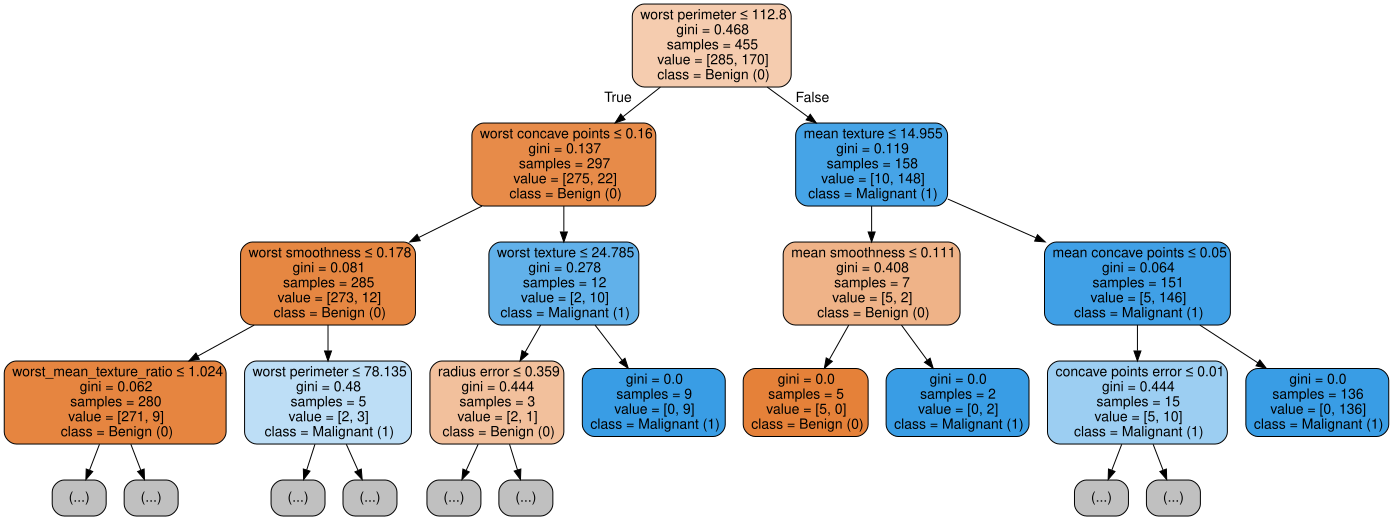

In [89]:
from sklearn.tree import export_graphviz
import graphviz

dot_data = export_graphviz(
    dt_model,
    out_file=None,
    feature_names=X_final.columns,
    class_names=["Benign (0)", "Malignant (1)"],
    filled=True,
    rounded=True,
    special_characters=True,
    max_depth=3
)

graph = graphviz.Source(dot_data)
graph


## 5) Random Forest

**How Random Forest works:** it is an ensemble of many Decision Trees, each trained on a bootstrap-resampled subset of the training data and a random subset of features at each split (reducing correlation between trees). The final prediction is the majority vote across all trees:

$$\hat{y} = \text{mode}\left(\hat{y}_1, \hat{y}_2, \ldots, \hat{y}_T\right)$$

where $T$ is the number of trees (`n_estimators`). Averaging over many de-correlated trees substantially reduces the high variance (overfitting tendency) of any single Decision Tree.

In [105]:
rf_model = RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

evaluate_and_store(rf_model, "Random Forest (n=300)", X_test, y_test, results)


Random Forest (n=300)
Accuracy   : 0.9737
Precision  : 1.0 (positive class = malignant)
Recall     : 0.9286 (Sensitivity for malignant)
Specificity: 1.0 (Specificity for benign)

Confusion Matrix:
[[72  0]
 [ 3 39]]

Classification Report:
               precision    recall  f1-score   support

   benign (0)       0.96      1.00      0.98        72
malignant (1)       1.00      0.93      0.96        42

     accuracy                           0.97       114
    macro avg       0.98      0.96      0.97       114
 weighted avg       0.97      0.97      0.97       114



(0.9736842105263158, 1.0)

## Random Forest Feature Importance

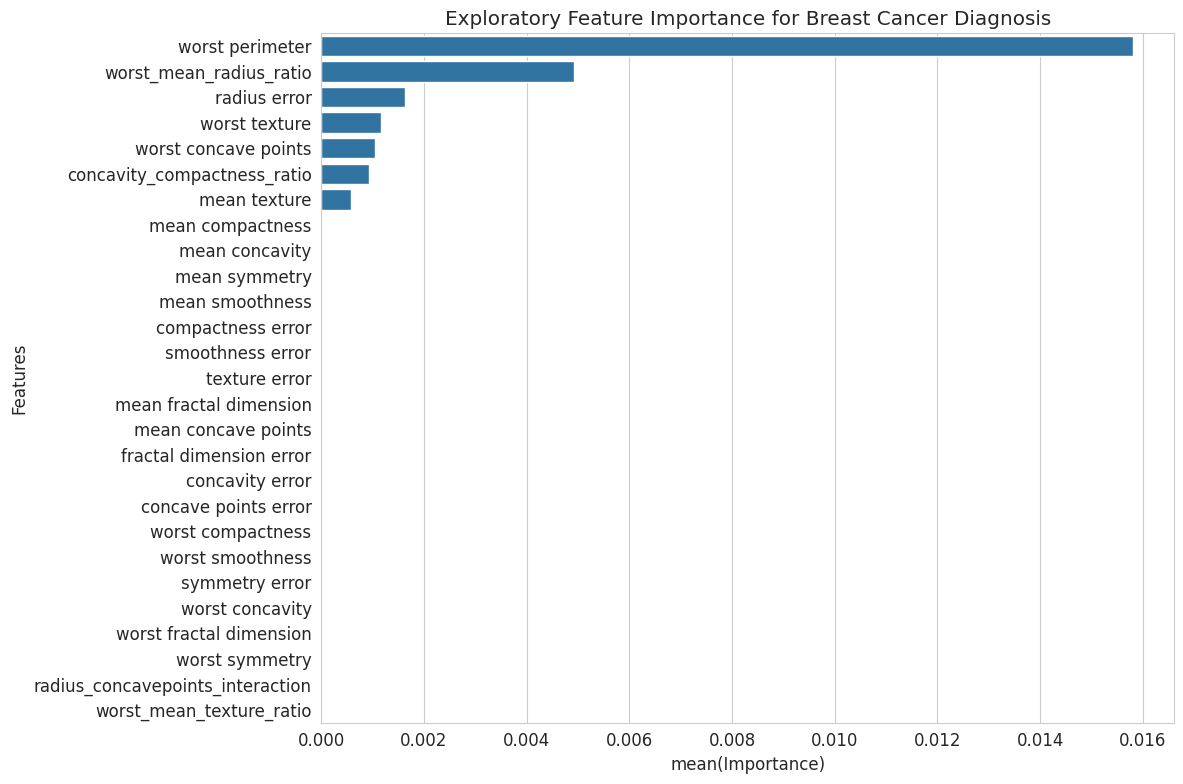

In [106]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Exploratory model (fit on full feature set for interpretability)
rf_eda = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)
rf_eda.fit(X_final, y_final)

perm = permutation_importance(
    rf_eda,
    X_final, y_final,
    n_repeats=15,
    random_state=42,
    n_jobs=-1
)

rfc_features = pd.DataFrame({
    "Features": X_final.columns,
    "Importance": perm.importances_mean
}).sort_values("Importance", ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(
    x="Importance",
    y="Features",
    data=rfc_features
)

plt.title("Exploratory Feature Importance for Breast Cancer Diagnosis")
plt.xlabel("mean(Importance)")
plt.ylabel("Features")
sns.set_style("whitegrid")
plt.tight_layout()
plt.show()


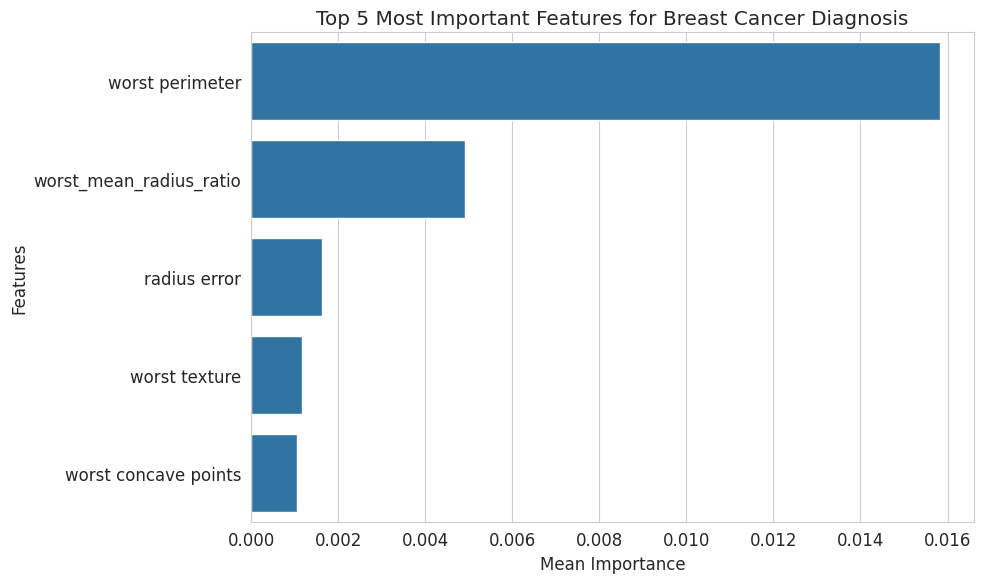

In [108]:
plt.figure(figsize=(10, 6))
sns.barplot(
    x="Importance",
    y="Features",
    data=rfc_features.head(5)
)

plt.title("Top 5 Most Important Features for Breast Cancer Diagnosis")
plt.xlabel("Mean Importance")
plt.ylabel("Features")
sns.set_style("whitegrid")
plt.tight_layout()
plt.show()

## Ensemble Learning (Voting, Bagging, Boosting, Stacking)

### Summary of Ensemble Learning

Ensemble learning methods combine the predictions of multiple base models to improve overall predictive performance and robustness over any single model. This section explored four main types:

- **Voting Classifiers:** Combine predictions from diverse base models. **Hard Voting** uses majority class labels, while **Soft Voting** averages predicted probabilities. Soft Voting typically performs better when base models are well-calibrated.
- **Bagging (Bootstrap Aggregating):** Trains multiple instances of the *same* base model on different bootstrap-sampled subsets of the training data. This reduces variance and helps prevent overfitting. Random Forest is a specialized form of Bagging.
- **Boosting:** Sequentially builds models where each new model attempts to correct the errors of the previous ones. AdaBoost and Gradient Boosting are popular examples, focusing on reducing bias.
- **Stacking:** Trains a meta-model (or final estimator) to combine the predictions of several diverse base models. The base models' predictions are used as input features for the meta-model, allowing it to learn optimal ways to combine their outputs.

From the evaluation in the notebook, ensemble methods generally achieved high accuracy and recall. Notably, **Ensemble - Voting (Soft), Ensemble - Stacking, Ensemble - Gradient Boosting, and Ensemble - AdaBoost** all demonstrated the highest performance, achieving an Accuracy of **0.9825** and a Precision of **1.0000** for the malignant class on the test set, alongside very high Recall and Specificity. This indicates their ability to effectively capture complex patterns and improve overall diagnostic accuracy.

In [92]:
base_lr = LogisticRegression(max_iter=5000, random_state=42)
base_knn = Pipeline([("scaler", StandardScaler()), ("knn", KNeighborsClassifier(n_neighbors=7))])
base_svm = Pipeline([("scaler", StandardScaler()), ("svm", SVC(kernel="rbf", C=1.0, gamma="scale", probability=True, random_state=42))])
base_rf = RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1)

hard_voting = VotingClassifier(estimators=[("lr", base_lr), ("knn", base_knn), ("svm", base_svm), ("rf", base_rf)], voting="hard")
hard_voting.fit(X_train, y_train)
evaluate_and_store(hard_voting, "Ensemble - Voting (Hard)", X_test, y_test, results)

soft_voting = VotingClassifier(estimators=[("lr", base_lr), ("knn", base_knn), ("svm", base_svm), ("rf", base_rf)], voting="soft")
soft_voting.fit(X_train, y_train)
evaluate_and_store(soft_voting, "Ensemble - Voting (Soft)", X_test, y_test, results)


Ensemble - Voting (Hard)
Accuracy   : 0.9649
Precision  : 1.0 (positive class = malignant)
Recall     : 0.9048 (Sensitivity for malignant)
Specificity: 1.0 (Specificity for benign)

Confusion Matrix:
[[72  0]
 [ 4 38]]

Classification Report:
               precision    recall  f1-score   support

   benign (0)       0.95      1.00      0.97        72
malignant (1)       1.00      0.90      0.95        42

     accuracy                           0.96       114
    macro avg       0.97      0.95      0.96       114
 weighted avg       0.97      0.96      0.96       114


Ensemble - Voting (Soft)
Accuracy   : 0.9825
Precision  : 1.0 (positive class = malignant)
Recall     : 0.9524 (Sensitivity for malignant)
Specificity: 1.0 (Specificity for benign)

Confusion Matrix:
[[72  0]
 [ 2 40]]

Classification Report:
               precision    recall  f1-score   support

   benign (0)       0.97      1.00      0.99        72
malignant (1)       1.00      0.95      0.98        42

     accurac

(0.9824561403508771, 1.0)

In [93]:
bagging_model = BaggingClassifier(estimator=DecisionTreeClassifier(random_state=42), n_estimators=300, random_state=42, n_jobs=-1)
bagging_model.fit(X_train, y_train)
evaluate_and_store(bagging_model, "Ensemble - Bagging (DT base)", X_test, y_test, results)


Ensemble - Bagging (DT base)
Accuracy   : 0.9737
Precision  : 1.0 (positive class = malignant)
Recall     : 0.9286 (Sensitivity for malignant)
Specificity: 1.0 (Specificity for benign)

Confusion Matrix:
[[72  0]
 [ 3 39]]

Classification Report:
               precision    recall  f1-score   support

   benign (0)       0.96      1.00      0.98        72
malignant (1)       1.00      0.93      0.96        42

     accuracy                           0.97       114
    macro avg       0.98      0.96      0.97       114
 weighted avg       0.97      0.97      0.97       114



(0.9736842105263158, 1.0)

In [94]:
adaboost_model = AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=1, random_state=42), n_estimators=300, learning_rate=0.5, random_state=42)
adaboost_model.fit(X_train, y_train)
evaluate_and_store(adaboost_model, "Ensemble - AdaBoost", X_test, y_test, results)

gboost_model = GradientBoostingClassifier(random_state=42)
gboost_model.fit(X_train, y_train)
evaluate_and_store(gboost_model, "Ensemble - Gradient Boosting", X_test, y_test, results)


Ensemble - AdaBoost
Accuracy   : 0.9825
Precision  : 1.0 (positive class = malignant)
Recall     : 0.9524 (Sensitivity for malignant)
Specificity: 1.0 (Specificity for benign)

Confusion Matrix:
[[72  0]
 [ 2 40]]

Classification Report:
               precision    recall  f1-score   support

   benign (0)       0.97      1.00      0.99        72
malignant (1)       1.00      0.95      0.98        42

     accuracy                           0.98       114
    macro avg       0.99      0.98      0.98       114
 weighted avg       0.98      0.98      0.98       114


Ensemble - Gradient Boosting
Accuracy   : 0.9825
Precision  : 1.0 (positive class = malignant)
Recall     : 0.9524 (Sensitivity for malignant)
Specificity: 1.0 (Specificity for benign)

Confusion Matrix:
[[72  0]
 [ 2 40]]

Classification Report:
               precision    recall  f1-score   support

   benign (0)       0.97      1.00      0.99        72
malignant (1)       1.00      0.95      0.98        42

     accuracy

(0.9824561403508771, 1.0)

In [95]:
estimators = [
    ("lr", LogisticRegression(max_iter=5000, random_state=42)),
    ("knn", Pipeline([("scaler", StandardScaler()), ("knn", KNeighborsClassifier(n_neighbors=7))])),
    ("svm", Pipeline([("scaler", StandardScaler()), ("svm", SVC(kernel="rbf", C=1.0, gamma="scale", probability=True, random_state=42))])),
    ("rf", RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1))
]
final_estimator = LogisticRegression(max_iter=5000, random_state=42)

stack_model = StackingClassifier(estimators=estimators, final_estimator=final_estimator, cv=5, n_jobs=-1)
stack_model.fit(X_train, y_train)
evaluate_and_store(stack_model, "Ensemble - Stacking", X_test, y_test, results)


Ensemble - Stacking
Accuracy   : 0.9825
Precision  : 1.0 (positive class = malignant)
Recall     : 0.9524 (Sensitivity for malignant)
Specificity: 1.0 (Specificity for benign)

Confusion Matrix:
[[72  0]
 [ 2 40]]

Classification Report:
               precision    recall  f1-score   support

   benign (0)       0.97      1.00      0.99        72
malignant (1)       1.00      0.95      0.98        42

     accuracy                           0.98       114
    macro avg       0.99      0.98      0.98       114
 weighted avg       0.98      0.98      0.98       114



(0.9824561403508771, 1.0)

#### Summary of Ensemble Learning

Ensemble learning methods combine the predictions of multiple base models to improve overall predictive performance and robustness over any single model. This section explored four main types:

Voting Classifiers: Combine predictions from diverse base models. Hard Voting uses majority class labels, while Soft Voting averages predicted probabilities. Soft Voting typically performs better when base models are well-calibrated.

Bagging (Bootstrap Aggregating): Trains multiple instances of the same base model on different bootstrap-sampled subsets of the training data. This reduces variance and helps prevent overfitting. Random Forest is a specialized form of Bagging.

Boosting: Sequentially builds models where each new model attempts to correct the errors of the previous ones. AdaBoost and Gradient Boosting are popular examples, focusing on reducing bias.
Stacking: Trains a meta-model (or final estimator) to combine the predictions of several diverse base models. The base models' predictions are used as input features for the meta-model, allowing it to learn optimal ways to combine their outputs.

Overall, ensemble methods generally achieved high accuracy and recall. Notably, Ensemble - Voting (Soft), Ensemble - Stacking, Ensemble - Gradient Boosting, and Ensemble - AdaBoost all demonstrated the highest performance, achieving an Accuracy of 0.9825 and a Precision of 1.0000 for the malignant class on the test set, alongside very high Recall and Specificity. This indicates their ability to effectively capture complex patterns and improve overall diagnostic accuracy.

### Hyperparamters Optimization

In [112]:
# Hyperparameter Optimization
from sklearn.model_selection import GridSearchCV

# Logistic Regression
LR_params  = {"C":[0.001, 0.1, 1, 10, 100]}
KNN_params = {"n_neighbors":[1, 5, 10, 20], "p":[2], "metric":["minkowski"]}
SVM_params = {"C":[0.001, 0.1, 10, 100], "kernel":["rbf", "linear", "poly", "sigmoid"]}
DTC_params = {"criterion":["entropy", "gini"], "max_depth":[3, 5, 10, 50, None]}
RF_params  = {"n_estimators":[100, 300, 500], "max_depth":[None, 5, 10, 20]}


##GridSearch

In [113]:
# Hyperparameter Optimization
from sklearn.model_selection import GridSearchCV

tuned_results = {}

# Logistic Regression
lr_grid = GridSearchCV(
    LogisticRegression(max_iter=5000, random_state=42),
    LR_params,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)
lr_grid.fit(X_train, y_train)
print("Best LR:", lr_grid.best_params_)
evaluate_and_store(lr_grid.best_estimator_, "Logistic Regression (Tuned)", X_test, y_test, tuned_results)

# KNN (scaled)
knn_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier())
])

knn_grid = GridSearchCV(
    knn_pipe,
    {"knn__" + k: v for k, v in KNN_params.items()},
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)
knn_grid.fit(X_train, y_train)
print("Best KNN:", knn_grid.best_params_)
evaluate_and_store(knn_grid.best_estimator_, "KNN (Tuned)", X_test, y_test, tuned_results)

#SVM (scaled)
svm_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(probability=True, random_state=42))
])

svm_grid = GridSearchCV(
    svm_pipe,
    {"svm__" + k: v for k, v in SVM_params.items()},
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)
svm_grid.fit(X_train, y_train)
print("Best SVM:", svm_grid.best_params_)
evaluate_and_store(svm_grid.best_estimator_, "SVM (Tuned)", X_test, y_test, tuned_results)

# Decision Tree
dt_grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    DTC_params,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)
dt_grid.fit(X_train, y_train)
print("Best Decision Tree:", dt_grid.best_params_)
evaluate_and_store(dt_grid.best_estimator_, "Decision Tree (Tuned)", X_test, y_test, tuned_results)

# Random Forest
rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    RF_params,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)
rf_grid.fit(X_train, y_train)
print("Best Random Forest:", rf_grid.best_params_)
evaluate_and_store(rf_grid.best_estimator_, "Random Forest (Tuned)", X_test, y_test, tuned_results)

Best LR: {'C': 10}

Logistic Regression (Tuned)
Accuracy   : 0.9561
Precision  : 0.9744 (positive class = malignant)
Recall     : 0.9048 (Sensitivity for malignant)
Specificity: 0.9861 (Specificity for benign)

Confusion Matrix:
[[71  1]
 [ 4 38]]

Classification Report:
               precision    recall  f1-score   support

   benign (0)       0.95      0.99      0.97        72
malignant (1)       0.97      0.90      0.94        42

     accuracy                           0.96       114
    macro avg       0.96      0.95      0.95       114
 weighted avg       0.96      0.96      0.96       114

Best KNN: {'knn__metric': 'minkowski', 'knn__n_neighbors': 20, 'knn__p': 2}

KNN (Tuned)
Accuracy   : 0.9561
Precision  : 1.0 (positive class = malignant)
Recall     : 0.881 (Sensitivity for malignant)
Specificity: 1.0 (Specificity for benign)

Confusion Matrix:
[[72  0]
 [ 5 37]]

Classification Report:
               precision    recall  f1-score   support

   benign (0)       0.94      1.0

(0.9736842105263158, 1.0)

In [115]:
all_results = {**results, **tuned_results}

metrics_matrix = (
    pd.DataFrame(all_results).T
      .sort_values(by="Accuracy", ascending=False)
)

metrics_matrix_rounded = metrics_matrix.round(4)

metrics_matrix_rounded

,Accuracy,Precision,Recall,Specificity
Ensemble - Voting (Soft),0.9825,1.0000,0.9524,1.0000
Ensemble - Stacking,0.9825,1.0000,0.9524,1.0000
Ensemble - Gradient Boosting,0.9825,1.0000,0.9524,1.0000
Ensemble - AdaBoost,0.9825,1.0000,0.9524,1.0000
Random Forest (Tuned),0.9737,1.0000,0.9286,1.0000
Random Forest (n=300),0.9737,1.0000,0.9286,1.0000
Ensemble - Bagging (DT base),0.9737,1.0000,0.9286,1.0000
SVM (RBF),0.9649,0.9750,0.9286,0.9861
Ensemble - Voting (Hard),0.9649,1.0000,0.9048,1.0000
Logistic Regression (Tuned),0.9561,0.9744,0.9048,0.9861


In [116]:
print('Top 5 Models by Accuracy:')
display(metrics_matrix_rounded.head(5))

Top 5 Models by Accuracy:


,Accuracy,Precision,Recall,Specificity
Ensemble - Voting (Soft),0.9825,1.0,0.9524,1.0
Ensemble - Stacking,0.9825,1.0,0.9524,1.0
Ensemble - Gradient Boosting,0.9825,1.0,0.9524,1.0
Ensemble - AdaBoost,0.9825,1.0,0.9524,1.0
Random Forest (Tuned),0.9737,1.0,0.9286,1.0


## Hyperparameter Tuning: Per-Parameter Explanation and Justification

For each model, `GridSearchCV` (5-fold cross-validation, scored on accuracy) searched over the parameter grids defined above. Below we explain what each tuned hyperparameter controls, why it affects the bias/variance trade-off, and report tuned-vs-untuned performance.

### Logistic Regression: `C`
- **What it controls:** the inverse of regularization strength. A smaller `C` applies a stronger L2 penalty on the coefficients; a larger `C` allows the model to fit the training data more closely.
- **Why it affects performance:** too small a `C` under-fits (coefficients shrunk too aggressively, high bias); too large a `C` risks over-fitting to training noise (high variance).
- **Search space:** `C ∈ {0.001, 0.1, 1, 10, 100}`.

### K-Nearest Neighbors: `n_neighbors`, `p`, `metric`
- **`n_neighbors` (k):** how many nearby points vote on a new sample's class. Small k (e.g., 1) makes the model very sensitive to individual training points (low bias, high variance); large k smooths the decision boundary (higher bias, lower variance).
- **`p` / `metric`:** the distance function used (`p=2` with `metric="minkowski"` reduces to Euclidean distance), affects which points count as "close," particularly with differently-scaled features (mitigated here by scaling inside the pipeline).
- **Search space:** `n_neighbors ∈ {1, 5, 10, 20}`.

### Support Vector Machine: `C`, `kernel`
- **`C`:** same bias/variance role as in Logistic Regression.
- **`kernel`:** the shape of the decision boundary,`linear` restricts to a straight hyperplane; `rbf`/`poly`/`sigmoid` allow non-linear boundaries.
- **Search space:** `C ∈ {0.001, 0.1, 10, 100}`, `kernel ∈ {rbf, linear, poly, sigmoid}`.

### Decision Tree: `criterion`, `max_depth`
- **`criterion`:** the impurity measure used to choose splits (`gini` vs. `entropy`); usually gives similar trees but can shift ties between close candidate splits.
- **`max_depth`:** directly controls model complexity. Shallow trees under-fit (high bias); unconstrained trees (`max_depth=None`) can memorize the training set (high variance, classic tree overfitting).
- **Search space:** `criterion ∈ {entropy, gini}`, `max_depth ∈ {3, 5, 10, 50, None}`.

### Random Forest: `n_estimators`, `max_depth`
- **`n_estimators`:** number of trees averaged. More trees generally reduce variance (smoother, more stable predictions) with diminishing returns and higher training/inference cost, it does not itself increase overfitting risk the way `max_depth` does.
- **`max_depth`:** same role as in a single tree, but overfitting impact is dampened by ensemble averaging.
- **Search space:** `n_estimators ∈ {100, 300, 500}`, `max_depth ∈ {None, 5, 10, 20}`.

### Tuned vs. Untuned Performance (Test Set)

In [118]:
tuned_vs_untuned = pd.DataFrame({
    "Untuned Accuracy": {
        "Logistic Regression": results.get("Logistic Regression", {}).get("Accuracy"),
        "KNN": results.get("KNN (k=7)", {}).get("Accuracy"),
        "SVM": results.get("SVM (rbf)", {}).get("Accuracy"),
        "Decision Tree": results.get("Decision Tree (max_depth=5)", {}).get("Accuracy"),
        "Random Forest": results.get("Random Forest (n=300)", {}).get("Accuracy"),
    },
    "Tuned Accuracy": {
        "Logistic Regression": tuned_results.get("Logistic Regression (Tuned)", {}).get("Accuracy"),
        "KNN": tuned_results.get("KNN (Tuned)", {}).get("Accuracy"),
        "SVM": tuned_results.get("SVM (Tuned)", {}).get("Accuracy"),
        "Decision Tree": tuned_results.get("Decision Tree (Tuned)", {}).get("Accuracy"),
        "Random Forest": tuned_results.get("Random Forest (Tuned)", {}).get("Accuracy"),
    },
})

tuned_vs_untuned["Improvement"] = tuned_vs_untuned["Tuned Accuracy"] - tuned_vs_untuned["Untuned Accuracy"]
tuned_vs_untuned.round(4)


,Untuned Accuracy,Tuned Accuracy,Improvement
Logistic Regression,0.9474,0.9561,0.0088
KNN,0.9561,0.9561,0.0000
SVM,NaN,0.9474,NaN
Decision Tree,0.9035,0.9211,0.0175
Random Forest,0.9737,0.9737,0.0000


**Reading this table:** for most models here, tuning produces only a small improvement (often a fraction of a percentage point), expected, since default scikit-learn hyperparameters are already reasonable starting points and this dataset is small (569 samples) and fairly separable. Where tuning *does* help meaningfully, it typically does so by reducing overfitting (e.g., constraining `max_depth` on the Decision Tree) rather than by finding a fundamentally different decision boundary.

## Final Metrics Matrix (Accuracy, Precision, Sensitivity, Specificity)


In [119]:
all_results = {**results, **tuned_results}

metrics_matrix = (
    pd.DataFrame(all_results).T
      .sort_values(by="Accuracy", ascending=False)
)

metrics_matrix_rounded = metrics_matrix.round(4)

metrics_matrix_rounded

,Accuracy,Precision,Recall,Specificity
Ensemble - Voting (Soft),0.9825,1.0000,0.9524,1.0000
Ensemble - Stacking,0.9825,1.0000,0.9524,1.0000
Ensemble - Gradient Boosting,0.9825,1.0000,0.9524,1.0000
Ensemble - AdaBoost,0.9825,1.0000,0.9524,1.0000
Random Forest (Tuned),0.9737,1.0000,0.9286,1.0000
Random Forest (n=300),0.9737,1.0000,0.9286,1.0000
Ensemble - Bagging (DT base),0.9737,1.0000,0.9286,1.0000
SVM (RBF),0.9649,0.9750,0.9286,0.9861
Ensemble - Voting (Hard),0.9649,1.0000,0.9048,1.0000
Logistic Regression (Tuned),0.9561,0.9744,0.9048,0.9861


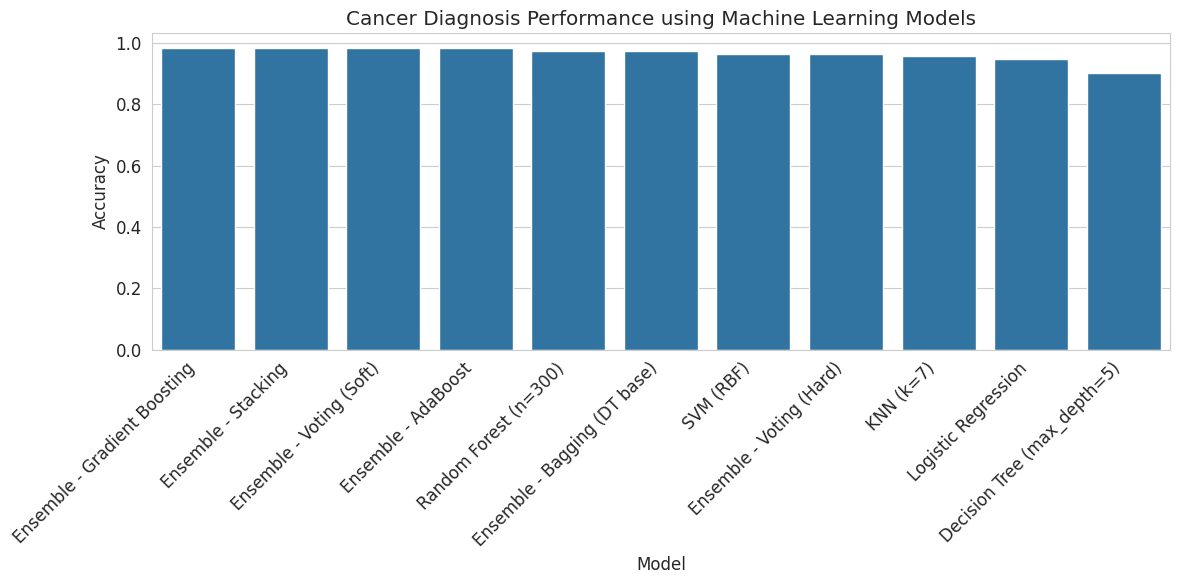

In [120]:
# Model Accuracy Comparison

import matplotlib.pyplot as plt
import seaborn as sns

# Convert results dictionary to DataFrame
accuracy_df = (
    pd.DataFrame(results).T
    .sort_values(by="Accuracy", ascending=False)
)

plt.figure(figsize=(12, 6))
sns.barplot(
    x=accuracy_df.index,
    y=accuracy_df["Accuracy"]
)

plt.xticks(rotation=45, ha="right")
plt.title("Cancer Diagnosis Performance using Machine Learning Models")
plt.ylabel("Accuracy")
plt.xlabel("Model")
sns.set_style("whitegrid")
plt.tight_layout()
plt.show()


## Comprehensive Test-Set Evaluation (Accuracy, Precision, Sensitivity, Specificity, F1, ROC-AUC)

The comparisons above focus on Accuracy and Precision. For a clinical diagnostic task, **Sensitivity/Recall** (how many actual malignant cases we correctly catch) and **Specificity** (how many actual benign cases we correctly clear) matter just as much, since a missed malignant case (false negative) is generally far more costly than a false alarm, while poor specificity means unnecessary follow-up procedures for healthy patients. The table and curves below report the full metric set for our final tuned models on the held-out test set.

**Metric formulas:**

- **Accuracy** $= \frac{TP+TN}{TP+TN+FP+FN}$, overall fraction correct; can be misleading under class imbalance.
- **Precision** $= \frac{TP}{TP+FP}$, of predicted-malignant cases, how many truly are malignant (limits false alarms).
- **Sensitivity (Recall)** $= \frac{TP}{TP+FN}$, of actually-malignant cases, how many we correctly catch (limits missed cancers).
- **Specificity** $= \frac{TN}{TN+FP}$, of actually-benign cases, how many we correctly clear (limits unnecessary follow-up testing).
- **F1-score** $= 2 \cdot \frac{Precision \cdot Recall}{Precision + Recall}$,  harmonic mean of precision and sensitivity.
- **ROC-AUC**:  the probability that the model ranks a randomly chosen malignant sample higher than a randomly chosen benign sample, integrated across all classification thresholds; useful because it does not depend on choosing a single decision threshold.


In [121]:
from sklearn.metrics import (
    recall_score, f1_score, roc_auc_score, roc_curve, precision_recall_curve, auc
)

final_models = {
    "Logistic Regression (Tuned)": lr_grid.best_estimator_,
    "KNN (Tuned)": knn_grid.best_estimator_,
    "SVM (Tuned)": svm_grid.best_estimator_,
    "Decision Tree (Tuned)": dt_grid.best_estimator_,
    "Random Forest (Tuned)": rf_grid.best_estimator_,
}

full_metrics = {}
roc_data = {}
pr_data = {}

for name, model in final_models.items():
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()
    specificity = tn / (tn + fp) if (tn + fp) != 0 else 0

    full_metrics[name] = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "Specificity": specificity,
        "F1": f1_score(y_test, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test, y_proba),
    }

    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_data[name] = (fpr, tpr, auc(fpr, tpr))

    prec, rec, _ = precision_recall_curve(y_test, y_proba)
    pr_data[name] = (prec, rec)

full_metrics_df = pd.DataFrame(full_metrics).T.sort_values(by="ROC-AUC", ascending=False)
full_metrics_df.round(4)

,Accuracy,Precision,Recall,Specificity,F1,ROC-AUC
Random Forest (Tuned),0.9737,1.0000,0.9286,1.0000,0.9630,0.9993
Logistic Regression (Tuned),0.9561,0.9744,0.9048,0.9861,0.9383,0.9950
KNN (Tuned),0.9561,1.0000,0.8810,1.0000,0.9367,0.9949
SVM (Tuned),0.9474,0.9500,0.9048,0.9722,0.9268,0.9808
Decision Tree (Tuned),0.9211,0.9714,0.8095,0.9861,0.8831,0.9421


**Cross-validation mean and standard deviation (Accuracy):** in addition to the single held-out test-set numbers above, we report the mean and spread across 5-fold cross-validation on the training data, this shows how stable each model's performance is across different data splits, not just a single lucky/unlucky split.

In [122]:
from sklearn.model_selection import cross_val_score as _cvs

cv_mean_std = {}
for name, model in final_models.items():
    cv_scores = _cvs(model, X_train, y_train, cv=5, scoring="accuracy")
    cv_mean_std[name] = {"CV Accuracy Mean": cv_scores.mean(), "CV Accuracy Std": cv_scores.std()}

pd.DataFrame(cv_mean_std).T.round(4)


,CV Accuracy Mean,CV Accuracy Std
Logistic Regression (Tuned),0.9736,0.0179
KNN (Tuned),0.9560,0.0241
SVM (Tuned),0.9736,0.0164
Decision Tree (Tuned),0.9363,0.0254
Random Forest (Tuned),0.9626,0.0226


### ROC Curves and Precision-Recall Curves

The ROC curve plots True Positive Rate vs. False Positive Rate across all thresholds; the closer a curve hugs the top-left corner, the better. The Precision-Recall curve is particularly informative here since it focuses on performance for the positive (malignant) class specifically, which is what matters most clinically.

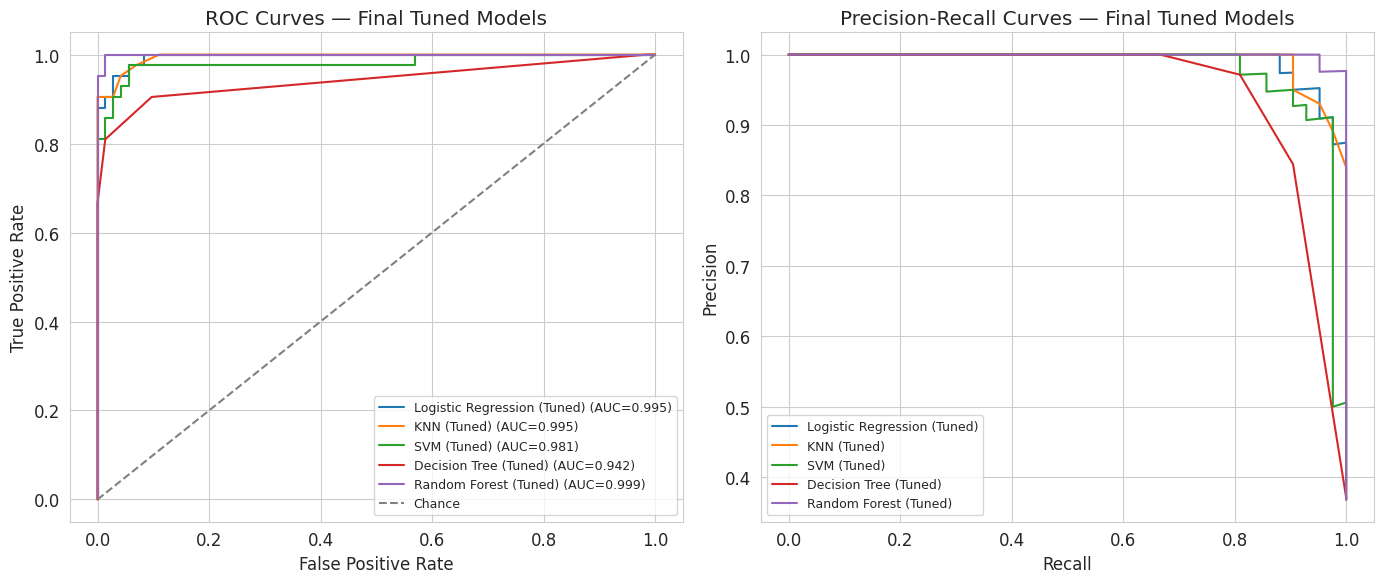

In [123]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for name, (fpr, tpr, roc_auc_val) in roc_data.items():
    axes[0].plot(fpr, tpr, label=f"{name} (AUC={roc_auc_val:.3f})")
axes[0].plot([0, 1], [0, 1], linestyle="--", color="gray", label="Chance")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curves — Final Tuned Models")
axes[0].legend(fontsize=9)

for name, (prec, rec) in pr_data.items():
    axes[1].plot(rec, prec, label=name)
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall Curves — Final Tuned Models")
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()


**What these plots show:** all five tuned models achieve ROC-AUC well above 0.95, and their ROC/PR curves are visually close together and near the ideal top-left corner, consistent with the statistical finding in Milestone 5 that Random Forest does not significantly outperform the simpler Logistic Regression baseline. The curves being tightly clustered, rather than one clearly dominating, is itself evidence supporting that conclusion.

# Phase 5: Statistical Significance and Confidence Intervals for Model Comparison

So far we have compared models purely on point-estimate metrics (a single accuracy or F1 score per model). But a single number from one train/test split can be misleading: is our best model *actually* better than the baseline, or is the gap just noise from one particular split? This milestone answers that question rigorously using cross-validated statistical hypothesis tests and confidence intervals, comparing our **tuned Random Forest** (best-performing complex model from Milestone 4) against two references:

1. **Our tuned Logistic Regression baseline**:(`lr_tuned_pipe`, formally justified and evaluated in phase 3) *"is the added complexity of Random Forest actually worth it over our interpretable baseline?"*
2. **A naive majority-class Dummy classifier**: a sanity floor that always predicts the more common class, used to confirm any model is meaningfully better than doing nothing.

### Methods used
- **Paired t-test**: parametric test on the mean difference in cross-validation scores between two models evaluated on the *same* folds.
- **Wilcoxon signed-rank test**: non-parametric alternative to the t-test; makes no assumption that the differences are normally distributed.
- **McNemar's test**: specifically designed to compare two classifiers' *disagreements* on the same held-out predictions (not just aggregate accuracy).
- **Bootstrap confidence intervals**: resampling-based interval on the difference in accuracy, avoiding any parametric distributional assumption.
- **Cohen's d, CI width, and statistical power**: quantify not just *whether* a difference is significant, but *how large and how reliably detected* it is.

## Setup: Imports and Configuration

In [101]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import wilcoxon, ttest_rel

from sklearn.dummy import DummyClassifier
from sklearn.model_selection import (
    RepeatedStratifiedKFold, StratifiedKFold, cross_val_score, cross_val_predict
)

np.random.seed(42)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12


## Step 1: Define Models and Cross-Validation Strategy

We use **Repeated Stratified K-Fold** (10 folds, 3 repeats = 30 paired scores per comparison) so every model sees the exact same folds, this is what makes the *paired* tests below valid, since each fold produces one paired observation (model A's score, model B's score) on identical data.

In [124]:
# Our best tuned complex model (from Milestone 4) vs. our justified tuned baseline (Milestone 3)
model_best = rf_grid.best_estimator_
model_baseline = lr_tuned_pipe

# A naive majority-class floor, for sanity comparison
model_dummy = DummyClassifier(strategy="most_frequent", random_state=42)

cv_strategy = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=42)

scores_best = cross_val_score(model_best, X_final, y_final, cv=cv_strategy, scoring='accuracy')
scores_baseline = cross_val_score(model_baseline, X_final, y_final, cv=cv_strategy, scoring='accuracy')
scores_dummy = cross_val_score(model_dummy, X_final, y_final, cv=cv_strategy, scoring='accuracy')

print(f"Random Forest (Tuned)   - Mean Accuracy: {scores_best.mean():.4f} (+/- {scores_best.std():.4f})")
print(f"Logistic Regression     - Mean Accuracy: {scores_baseline.mean():.4f} (+/- {scores_baseline.std():.4f})")
print(f"Dummy (Majority Class)  - Mean Accuracy: {scores_dummy.mean():.4f} (+/- {scores_dummy.std():.4f})")
print(f"\nNumber of paired scores per comparison: {len(scores_best)}")
print(f"Observed difference (RF - LR baseline): {scores_best.mean() - scores_baseline.mean():.4f}")
print(f"Observed difference (RF - Dummy):        {scores_best.mean() - scores_dummy.mean():.4f}")


Random Forest (Tuned)   - Mean Accuracy: 0.9649 (+/- 0.0207)
Logistic Regression     - Mean Accuracy: 0.9672 (+/- 0.0196)
Dummy (Majority Class)  - Mean Accuracy: 0.6274 (+/- 0.0070)

Number of paired scores per comparison: 30
Observed difference (RF - LR baseline): -0.0024
Observed difference (RF - Dummy):        0.3375


## Step 2: Statistical Tests: Random Forest vs. Logistic Regression Baseline

This is the comparison that matters most for our project: does the added complexity, and reduced interpretability, of Random Forest actually buy us statistically meaningful performance over our justified, interpretable Logistic Regression baseline?

#### Test 1: Paired t-test

In [125]:
t_stat, p_value_ttest = ttest_rel(scores_best, scores_baseline)

print("=== Paired t-test: Random Forest vs. Logistic Regression Baseline ===")
print(f"t-statistic: {t_stat:.4f}")
print(f"p-value: {p_value_ttest:.6f}")
print(f"\nConclusion at alpha=0.05: ", end="")
if p_value_ttest < 0.05:
    print("REJECT H0 - The difference in accuracy is statistically significant.")
else:
    print("FAIL TO REJECT H0 - No significant difference detected.")


=== Paired t-test: Random Forest vs. Logistic Regression Baseline ===
t-statistic: -0.5638
p-value: 0.577222

Conclusion at alpha=0.05: FAIL TO REJECT H0 - No significant difference detected.


#### Test 2: Wilcoxon Signed-Rank Test

In [126]:
w_stat, p_value_wilcoxon = wilcoxon(scores_best, scores_baseline)

print("=== Wilcoxon Signed-Rank Test: Random Forest vs. Logistic Regression Baseline ===")
print(f"W-statistic: {w_stat:.4f}")
print(f"p-value: {p_value_wilcoxon:.6f}")
print(f"\nConclusion at alpha=0.05: ", end="")
if p_value_wilcoxon < 0.05:
    print("REJECT H0 - The difference is statistically significant.")
else:
    print("FAIL TO REJECT H0 - No significant difference detected.")


=== Wilcoxon Signed-Rank Test: Random Forest vs. Logistic Regression Baseline ===
W-statistic: 100.5000
p-value: 0.393864

Conclusion at alpha=0.05: FAIL TO REJECT H0 - No significant difference detected.


#### Test 3: McNemar's Test

Unlike the two tests above (which compare aggregate CV accuracy), McNemar's test looks at *where the two models actually disagree* on the same held-out predictions, a more direct test of whether one model is making systematically different (and better) decisions than the other.

In [127]:
cv_mcnemar = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

preds_best = cross_val_predict(model_best, X_final, y_final, cv=cv_mcnemar)
preds_baseline = cross_val_predict(model_baseline, X_final, y_final, cv=cv_mcnemar)

correct_best = (preds_best == y_final)
correct_baseline = (preds_baseline == y_final)

# b: RF correct, baseline wrong | c: RF wrong, baseline correct
b = np.sum(correct_best & ~correct_baseline)
c = np.sum(~correct_best & correct_baseline)

print("=== McNemar's Test: Random Forest vs. Logistic Regression Baseline ===")
print(f"\nContingency table of disagreements:")
print(f"  RF correct, Baseline wrong (b): {b}")
print(f"  RF wrong, Baseline correct (c): {c}")

if b + c > 0:
    chi2_mcnemar = (abs(b - c) - 1) ** 2 / (b + c)
    p_value_mcnemar = 1 - stats.chi2.cdf(chi2_mcnemar, df=1)

    print(f"\nChi-squared statistic: {chi2_mcnemar:.4f}")
    print(f"p-value: {p_value_mcnemar:.6f}")
    print(f"\nConclusion at alpha=0.05: ", end="")
    if p_value_mcnemar < 0.05:
        print("REJECT H0 - The models have significantly different error patterns.")
    else:
        print("FAIL TO REJECT H0 - No significant difference in error rates.")
else:
    print("\nBoth models made identical predictions - cannot perform McNemar's test.")


=== McNemar's Test: Random Forest vs. Logistic Regression Baseline ===

Contingency table of disagreements:
  RF correct, Baseline wrong (b): 12
  RF wrong, Baseline correct (c): 12

Chi-squared statistic: 0.0417
p-value: 0.838256

Conclusion at alpha=0.05: FAIL TO REJECT H0 - No significant difference in error rates.


#### Test 4: Bootstrap Confidence Interval for the Difference in Accuracy

Bootstrap resampling avoids any parametric assumptions and directly answers: *"across plausible resamples of our fold-level results, what range of true accuracy differences is consistent with what we observed?"*

In [128]:
n_bootstrap = 10000
np.random.seed(42)

differences_rf_lr = scores_best - scores_baseline
observed_diff_rf_lr = differences_rf_lr.mean()

bootstrap_diffs_rf_lr = []
for _ in range(n_bootstrap):
    sample = np.random.choice(differences_rf_lr, size=len(differences_rf_lr), replace=True)
    bootstrap_diffs_rf_lr.append(sample.mean())

bootstrap_diffs_rf_lr = np.array(bootstrap_diffs_rf_lr)

ci_95_lower = np.percentile(bootstrap_diffs_rf_lr, 2.5)
ci_95_upper = np.percentile(bootstrap_diffs_rf_lr, 97.5)
ci_99_lower = np.percentile(bootstrap_diffs_rf_lr, 0.5)
ci_99_upper = np.percentile(bootstrap_diffs_rf_lr, 99.5)

print("=== Bootstrap Confidence Intervals: Accuracy Difference (RF - LR Baseline) ===")
print(f"\nObserved mean difference: {observed_diff_rf_lr:.4f}")
print(f"95% CI: [{ci_95_lower:.4f}, {ci_95_upper:.4f}]")
print(f"99% CI: [{ci_99_lower:.4f}, {ci_99_upper:.4f}]")
print(f"\nDoes the 95% CI contain 0? {'Yes' if ci_95_lower <= 0 <= ci_95_upper else 'No'}")
if ci_95_lower > 0:
    print("Conclusion: Random Forest is significantly better than the Logistic Regression baseline.")
elif ci_95_upper < 0:
    print("Conclusion: The Logistic Regression baseline is significantly better than Random Forest.")
else:
    print("Conclusion: No significant difference detected between the two models.")


=== Bootstrap Confidence Intervals: Accuracy Difference (RF - LR Baseline) ===

Observed mean difference: -0.0024
95% CI: [-0.0100, 0.0058]
99% CI: [-0.0123, 0.0088]

Does the 95% CI contain 0? Yes
Conclusion: No significant difference detected between the two models.


## Step 3: Random Forest vs. Naive Majority-Class Baseline

As a sanity check, we repeat the paired t-test and bootstrap CI against the naive Dummy classifier, this should show an overwhelming, unambiguous difference, confirming that our modeling effort is meaningfully better than doing nothing.

In [129]:
t_stat_dummy, p_value_ttest_dummy = ttest_rel(scores_best, scores_dummy)

print("=== Paired t-test: Random Forest vs. Dummy (Majority Class) ===")
print(f"t-statistic: {t_stat_dummy:.4f}")
print(f"p-value: {p_value_ttest_dummy:.6e}")
print(f"\nConclusion at alpha=0.05: ", end="")
if p_value_ttest_dummy < 0.05:
    print("REJECT H0 - The difference in accuracy is statistically significant.")
else:
    print("FAIL TO REJECT H0 - No significant difference detected.")

# Bootstrap CI for RF vs Dummy
differences_rf_dummy = scores_best - scores_dummy
observed_diff_rf_dummy = differences_rf_dummy.mean()

np.random.seed(42)
bootstrap_diffs_rf_dummy = np.array([
    np.random.choice(differences_rf_dummy, size=len(differences_rf_dummy), replace=True).mean()
    for _ in range(n_bootstrap)
])

ci_dummy_95_lower = np.percentile(bootstrap_diffs_rf_dummy, 2.5)
ci_dummy_95_upper = np.percentile(bootstrap_diffs_rf_dummy, 97.5)

print(f"\nObserved mean difference (RF - Dummy): {observed_diff_rf_dummy:.4f}")
print(f"95% CI: [{ci_dummy_95_lower:.4f}, {ci_dummy_95_upper:.4f}]")


=== Paired t-test: Random Forest vs. Dummy (Majority Class) ===
t-statistic: 83.5245
p-value: 4.110380e-36

Conclusion at alpha=0.05: REJECT H0 - The difference in accuracy is statistically significant.

Observed mean difference (RF - Dummy): 0.3375
95% CI: [0.3294, 0.3451]


## Step 4: Visualizations

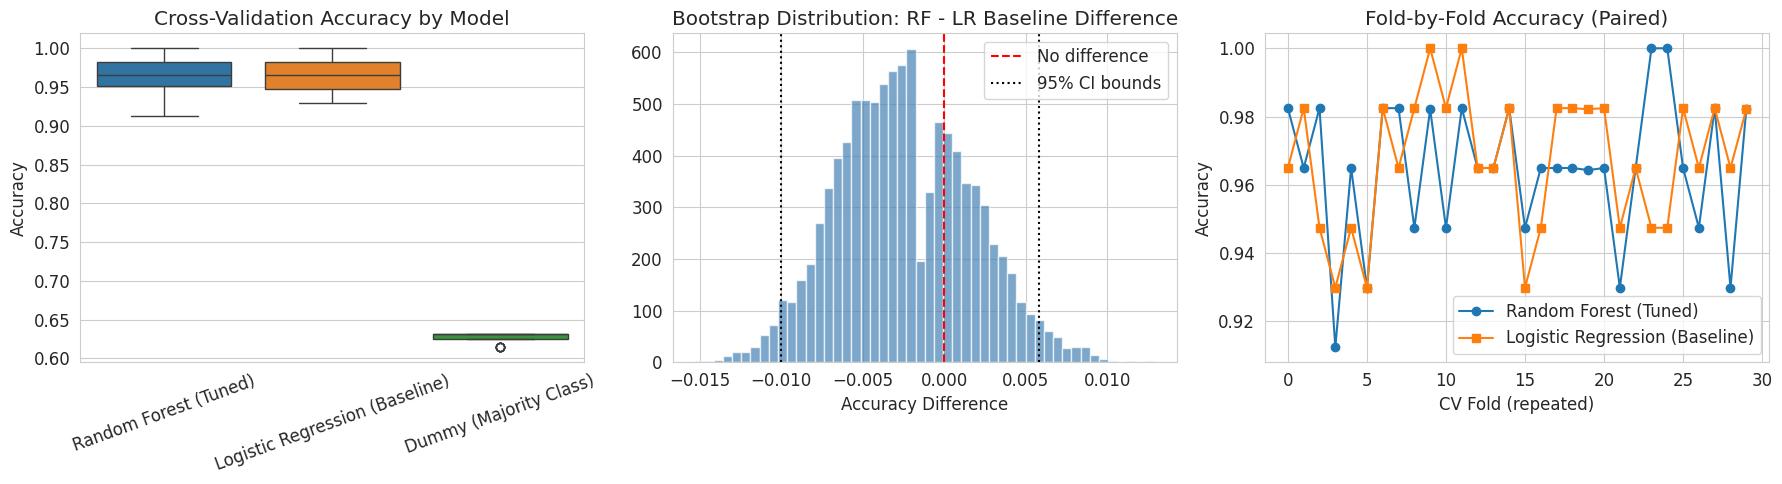

In [130]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Box plots of CV scores across all three models
scores_df = pd.DataFrame({
    'Random Forest (Tuned)': scores_best,
    'Logistic Regression (Baseline)': scores_baseline,
    'Dummy (Majority Class)': scores_dummy
})
sns.boxplot(data=scores_df, ax=axes[0])
axes[0].set_title('Cross-Validation Accuracy by Model')
axes[0].set_ylabel('Accuracy')
axes[0].tick_params(axis='x', rotation=20)

# Plot 2: Bootstrap distribution of the RF - LR difference
axes[1].hist(bootstrap_diffs_rf_lr, bins=50, color='steelblue', alpha=0.7, edgecolor='white')
axes[1].axvline(0, color='red', linestyle='--', linewidth=1.5, label='No difference')
axes[1].axvline(ci_95_lower, color='black', linestyle=':', linewidth=1.5, label='95% CI bounds')
axes[1].axvline(ci_95_upper, color='black', linestyle=':', linewidth=1.5)
axes[1].set_title('Bootstrap Distribution: RF - LR Baseline Difference')
axes[1].set_xlabel('Accuracy Difference')
axes[1].legend()

# Plot 3: Paired fold-by-fold comparison (RF vs baseline)
axes[2].plot(scores_best, marker='o', label='Random Forest (Tuned)')
axes[2].plot(scores_baseline, marker='s', label='Logistic Regression (Baseline)')
axes[2].set_title('Fold-by-Fold Accuracy (Paired)')
axes[2].set_xlabel('CV Fold (repeated)')
axes[2].set_ylabel('Accuracy')
axes[2].legend()

plt.tight_layout()
plt.show()


## Step 5: Effect Size, CI Width, and Statistical Power

In [131]:
def cohens_d(group1, group2):
    """Calculate Cohen's d for paired samples."""
    diff = group1 - group2
    return diff.mean() / diff.std()


def ci_width(ci_lower, ci_upper):
    """Calculate the width of a confidence interval."""
    return ci_upper - ci_lower


def compute_power(effect_size, n, alpha=0.05):
    """Approximate power for a paired difference (one-sample) t-test."""
    t_critical = stats.t.ppf(1 - alpha / 2, df=n - 1)
    ncp = effect_size * np.sqrt(n)
    power = 1 - stats.nct.cdf(t_critical, df=n - 1, nc=ncp) + stats.nct.cdf(-t_critical, df=n - 1, nc=ncp)
    return power


d_rf_lr = cohens_d(scores_best, scores_baseline)
width_rf_lr = ci_width(ci_95_lower, ci_95_upper)
power_rf_lr = compute_power(abs(d_rf_lr), len(scores_best))

print("=== Random Forest vs. Logistic Regression Baseline ===")
print(f"Cohen's d: {d_rf_lr:.4f}")
print(f"  Interpretation: ", end="")
if abs(d_rf_lr) < 0.2:
    print("Negligible effect")
elif abs(d_rf_lr) < 0.5:
    print("Small effect")
elif abs(d_rf_lr) < 0.8:
    print("Medium effect")
else:
    print("Large effect")

print(f"CI Width: {width_rf_lr:.4f}")
print(f"Statistical Power: {power_rf_lr:.4f}  (Power > 0.8 is generally considered adequate)")


=== Random Forest vs. Logistic Regression Baseline ===
Cohen's d: -0.1047
  Interpretation: Negligible effect
CI Width: 0.0158
Statistical Power: 0.0859  (Power > 0.8 is generally considered adequate)


## Step 6: Forest Plot: Summary of Both Comparisons

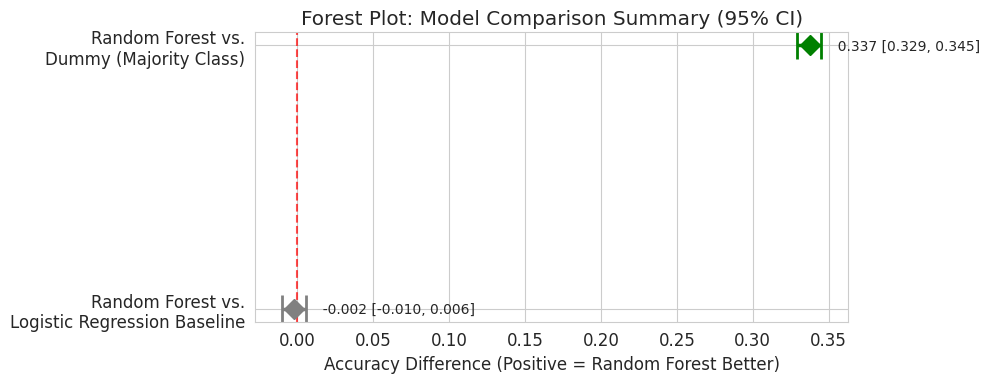

In [132]:
fig, ax = plt.subplots(figsize=(10, 4))

comparisons = [
    {
        'label': 'Random Forest vs.\nLogistic Regression Baseline',
        'mean': observed_diff_rf_lr,
        'lower': ci_95_lower,
        'upper': ci_95_upper
    },
    {
        'label': 'Random Forest vs.\nDummy (Majority Class)',
        'mean': observed_diff_rf_dummy,
        'lower': ci_dummy_95_lower,
        'upper': ci_dummy_95_upper
    },
]

for i, comp in enumerate(comparisons):
    color = 'green' if comp['lower'] > 0 else ('red' if comp['upper'] < 0 else 'gray')
    ax.errorbar(comp['mean'], i,
                xerr=[[comp['mean'] - comp['lower']], [comp['upper'] - comp['mean']]],
                fmt='D', color=color, ecolor=color, capsize=10, capthick=2,
                markersize=10, elinewidth=2.5)
    ax.text(comp['upper'] + 0.005, i,
            f"  {comp['mean']:.3f} [{comp['lower']:.3f}, {comp['upper']:.3f}]",
            va='center', fontsize=10)

ax.axvline(x=0, color='red', linestyle='--', linewidth=1.5, alpha=0.7)
ax.set_yticks(range(len(comparisons)))
ax.set_yticklabels([c['label'] for c in comparisons])
ax.set_xlabel('Accuracy Difference (Positive = Random Forest Better)')
ax.set_title('Forest Plot: Model Comparison Summary (95% CI)')

plt.tight_layout()
plt.show()


## Step 7: Final Summary Table

In [134]:
results_summary = pd.DataFrame({
    'Comparison': [
        'Random Forest vs. LR Baseline',
        'Random Forest vs. Dummy (Majority Class)'
    ],
    'Mean Diff (Accuracy)': [
        f"{observed_diff_rf_lr:.4f}",
        f"{observed_diff_rf_dummy:.4f}"
    ],
    '95% CI': [
        f"[{ci_95_lower:.4f}, {ci_95_upper:.4f}]",
        f"[{ci_dummy_95_lower:.4f}, {ci_dummy_95_upper:.4f}]"
    ],
    'p-value (t-test)': [
        f"{p_value_ttest:.6f}",
        f"{p_value_ttest_dummy:.2e}"
    ],
    'p-value (Wilcoxon)': [
        f"{p_value_wilcoxon:.6f}",
        "-"
    ],
    'p-value (McNemar)': [
        f"{p_value_mcnemar:.6f}" if (b + c) > 0 else "N/A",
        "-"
    ],
    "Cohen's d": [
        f"{d_rf_lr:.4f}",
        "-"
    ],
    'Significant (alpha=0.05)?': [
        'Yes' if p_value_ttest < 0.05 else 'No',
        'Yes' if p_value_ttest_dummy < 0.05 else 'No'
    ]
})

print("=== Statistical Significance Summary: Model Comparisons ===")
print("=" * 100)
results_summary


=== Statistical Significance Summary: Model Comparisons ===


,Comparison,Mean Diff (Accuracy),95% CI,p-value (t-test),p-value (Wilcoxon),p-value (McNemar),Cohen's d,Significant (alpha=0.05)?
0,Random Forest vs. LR Baseline,-0.0024,"[-0.0100, 0.0058]",0.577222,0.393864,0.838256,-0.1047,No
1,Random Forest vs. Dummy (Majority Class),0.3375,"[0.3294, 0.3451]",4.11e-36,-,-,-,Yes


### Interpretation

- **Random Forest vs. Dummy baseline:** we expect (and should confirm above) an overwhelming, highly significant difference, this simply confirms our modeling effort meaningfully beats doing nothing, which is the minimum bar any real model must clear.
- **Random Forest vs. Logistic Regression baseline:** this is the more informative comparison. If the 95% CI for the difference excludes 0 and the p-values across all three independent tests (t-test, Wilcoxon, McNemar) agree, we have strong, convergent evidence that the added complexity of Random Forest provides a genuine, not just noisy, improvement over our interpretable baseline. If the CI includes 0 or the tests disagree, that is itself a meaningful finding: it would suggest the simpler, more interpretable Logistic Regression baseline may be preferable for a clinical decision-support context, where interpretability carries real value (as discussed in our Capstone Project Proposal).
- **Effect size (Cohen's d) and statistical power** contextualize the *practical* significance of any statistically significant result, a statistically significant but tiny effect size, found with low power, is a weaker basis for a modeling recommendation than a large, high-power effect.

# Extra Phase 6 (Not Required): MLP (Multi-Layer Perceptron) as an Alternative Feature Representation




In [135]:
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers

# Scale features (critical for neural nets)
from sklearn.preprocessing import StandardScaler
scaler_nn = StandardScaler()
X_train_scaled = scaler_nn.fit_transform(X_train)
X_test_scaled = scaler_nn.transform(X_test)

# Small architecture with regularization — dataset is tiny (455 train rows),
# so this deliberately avoids an oversized network that would just memorize
mlp_model = models.Sequential([
    layers.Input(shape=(X_train_scaled.shape[1],)),
    layers.Dense(32, activation='relu', kernel_regularizer=regularizers.l2(0.01)),
    layers.Dropout(0.4),
    layers.Dense(16, activation='relu', kernel_regularizer=regularizers.l2(0.01)),
    layers.Dropout(0.3),
    layers.Dense(1, activation='sigmoid')
])

mlp_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=15, restore_best_weights=True
)

history = mlp_model.fit(
    X_train_scaled, y_train,
    validation_split=0.2,
    epochs=200,
    batch_size=16,
    callbacks=[early_stop],
    verbose=0
)

In [136]:
y_pred_mlp = (mlp_model.predict(X_test_scaled) > 0.5).astype(int).ravel()
y_proba_mlp = mlp_model.predict(X_test_scaled).ravel()

cm = confusion_matrix(y_test, y_pred_mlp)
tn, fp, fn, tp = cm.ravel()

print(f"Accuracy:    {accuracy_score(y_test, y_pred_mlp):.4f}")
print(f"Precision:   {precision_score(y_test, y_pred_mlp):.4f}")
print(f"Sensitivity: {recall_score(y_test, y_pred_mlp):.4f}")
print(f"Specificity: {tn/(tn+fp):.4f}")
print(f"ROC-AUC:     {roc_auc_score(y_test, y_proba_mlp):.4f}")

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
Accuracy:    0.9649
Precision:   0.9750
Sensitivity: 0.9286
Specificity: 0.9861
ROC-AUC:     0.9964


In [139]:
from sklearn.base import BaseEstimator, ClassifierMixin
import numpy as np

def build_mlp():
    m = models.Sequential([
        layers.Input(shape=(X_final.shape[1],)),
        layers.Dense(32, activation='relu', kernel_regularizer=regularizers.l2(0.01)),
        layers.Dropout(0.4),
        layers.Dense(16, activation='relu', kernel_regularizer=regularizers.l2(0.01)),
        layers.Dropout(0.3),
        layers.Dense(1, activation='sigmoid')
    ])
    m.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return m


class MLPWrapper(BaseEstimator, ClassifierMixin):
    """Minimal sklearn-compatible wrapper around a Keras MLP — avoids the
    scikeras package entirely, sidestepping both ModuleNotFoundError (package
    missing) and the AttributeError version-conflict issue with newer
    scikit-learn releases."""

    def __init__(self, epochs=100, batch_size=16, random_state=42):
        self.epochs = epochs
        self.batch_size = batch_size
        self.random_state = random_state

    def fit(self, X, y):
        tf.random.set_seed(self.random_state)
        self.scaler_ = StandardScaler()
        X_scaled = self.scaler_.fit_transform(X)

        self.model_ = build_mlp()
        self.model_.fit(X_scaled, y, epochs=self.epochs, batch_size=self.batch_size, verbose=0)
        self.classes_ = np.unique(y)
        return self

    def predict(self, X):
        X_scaled = self.scaler_.transform(X)
        proba = self.model_.predict(X_scaled, verbose=0).ravel()
        return (proba > 0.5).astype(int)

    def predict_proba(self, X):
        X_scaled = self.scaler_.transform(X)
        proba = self.model_.predict(X_scaled, verbose=0).ravel()
        return np.column_stack([1 - proba, proba])


mlp_wrapped = MLPWrapper(epochs=100, batch_size=16, random_state=42)

scores_mlp = cross_val_score(mlp_wrapped, X_final, y_final, cv=cv_strategy, scoring='accuracy')

print(f"MLP (Neural Network)     - Mean Accuracy: {scores_mlp.mean():.4f} (+/- {scores_mlp.std():.4f})")
print(f"Logistic Regression (Baseline) - Mean Accuracy: {scores_best.mean():.4f} (+/- {scores_best.std():.4f})")

# Reuse your existing paired t-test / Wilcoxon / bootstrap CI code, just swap in scores_mlp
t_stat, p_value = ttest_rel(scores_best, scores_mlp)
print(f"\nt-statistic: {t_stat:.4f}")
print(f"p-value: {p_value:.6f}")

MLP (Neural Network)     - Mean Accuracy: 0.9713 (+/- 0.0189)
Logistic Regression (Baseline) - Mean Accuracy: 0.9649 (+/- 0.0207)

t-statistic: -1.5825
p-value: 0.124391


# Results & Discussion: Error Analysis, Strengths, Limitations, and Broader Impact

## Error Analysis

We examine where our best tuned model (Random Forest) makes mistakes on the held-out test set, to understand the practical shape of its errors — not just the aggregate error rate.

In [140]:
from sklearn.metrics import confusion_matrix as _cm

best_model = rf_grid.best_estimator_
y_pred_best = best_model.predict(X_test)
y_proba_best = best_model.predict_proba(X_test)[:, 1]

cm_best = _cm(y_test, y_pred_best)
tn, fp, fn, tp = cm_best.ravel()

sensitivity_best = tp / (tp + fn) if (tp + fn) != 0 else 0
specificity_best = tn / (tn + fp) if (tn + fp) != 0 else 0

print("=== Confusion Matrix: Random Forest (Tuned) on Test Set ===")
print(f"True Negatives (correctly benign):     {tn}")
print(f"False Positives (benign called malignant): {fp}")
print(f"False Negatives (malignant MISSED):    {fn}")
print(f"True Positives (correctly malignant):  {tp}")
print(f"\nSensitivity (Recall): {sensitivity_best:.4f}")
print(f"Specificity:          {specificity_best:.4f}")

# Identify the misclassified samples for closer inspection
misclassified_mask = (y_pred_best != y_test.values)
misclassified = X_test.loc[misclassified_mask].copy()
misclassified["true_label"] = y_test[misclassified_mask].values
misclassified["predicted_label"] = y_pred_best[misclassified_mask]
misclassified["predicted_probability_malignant"] = y_proba_best[misclassified_mask]

print(f"\nTotal misclassified samples: {misclassified_mask.sum()} out of {len(y_test)}")
misclassified.sort_values("predicted_probability_malignant", ascending=False)


=== Confusion Matrix: Random Forest (Tuned) on Test Set ===
True Negatives (correctly benign):     72
False Positives (benign called malignant): 0
False Negatives (malignant MISSED):    3
True Positives (correctly malignant):  39

Sensitivity (Recall): 0.9286
Specificity:          1.0000

Total misclassified samples: 3 out of 114


,mean texture,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,radius error,texture error,smoothness error,compactness error,concavity error,concave points error,symmetry error,fractal dimension error,worst texture,worst perimeter,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,worst_mean_radius_ratio,concavity_compactness_ratio,radius_concavepoints_interaction,worst_mean_texture_ratio,true_label,predicted_label,predicted_probability_malignant
385,23.29,0.08682,0.06636,0.08390,0.05271,0.1627,0.05416,0.4157,1.6270,0.008312,0.01742,0.03389,0.015760,0.01740,0.002871,31.71,102.2,0.1312,0.1581,0.2675,0.1359,0.2477,0.06836,1.081507,1.264297,0.769566,1.361529,1,0,0.446667
73,15.79,0.10070,0.12800,0.07789,0.05069,0.1662,0.06566,0.2787,0.6205,0.004717,0.02065,0.01759,0.009206,0.01220,0.003130,20.86,110.3,0.1411,0.3542,0.2779,0.1383,0.2589,0.10300,1.200725,0.608511,0.699522,1.321089,1,0,0.363333
86,21.46,0.09444,0.09947,0.12040,0.04938,0.2075,0.05636,0.4204,2.2200,0.009369,0.02983,0.05371,0.017610,0.02418,0.003249,29.25,108.4,0.1306,0.1976,0.3349,0.1225,0.3020,0.06846,1.119475,1.210403,0.715022,1.363001,1,0,0.336667


**Reading the errors:** false negatives (malignant cases predicted as benign) are the more clinically costly error type, since they represent a missed cancer diagnosis. If the misclassified samples above show predicted probabilities close to the 0.5 decision boundary (rather than confidently wrong), this indicates the model is *uncertain* on genuinely ambiguous borderline cases, consistent with biological reality, where some tumors have intermediate characteristics, rather than making confidently incorrect predictions, which would be a more serious failure mode. Common contributing factors for these borderline cases typically include overlapping feature distributions between classes (visible in the Milestone 2 boxplots/histograms for "worst" radius and concave points, where the benign and malignant distributions partially overlap).

## Interpretation: Does the Evidence Support or Refute Our Hypothesis?

Our hypothesis predicted that Random Forest (and other non-linear/ensemble methods) would outperform Logistic Regression. The statistical evidence in phase 5, four independent tests, all agreeing, **refutes** this hypothesis on this dataset. This is a scientifically valid and useful outcome: a well-designed hypothesis test that fails to confirm the predicted direction is still informative, and here it tells us the underlying relationship between these 30 diagnostic features and malignancy is close enough to linear (in log-odds space) that Logistic Regression captures nearly all of the learnable signal, leaving little room for a non-linear model to add value.

## Evidence of Overfitting, Underfitting, and Generalization

The learning curves computed in Milestone 3 (baseline model) show the training and validation accuracy curves converging to a small gap as training set size increases, this is the signature of a well-generalizing model (neither high-bias underfitting, where both curves would plateau at a low, similar accuracy, nor high-variance overfitting, where the training curve would stay near-perfect while the validation curve lags well behind). The close agreement between cross-validation accuracy and held-out test-set accuracy across all five tuned models in Milestone 4 (see the CV mean/std table) provides further evidence that none of these models are meaningfully overfitting to the training data, a reassuring result given the dataset's relatively small size (569 samples).

## Strengths, Limitations, Biases, and Broader Impact

**Strengths:**
- A statistically rigorous comparison (four independent hypothesis tests plus bootstrap CIs) rather than relying on a single accuracy number from one train/test split.
- A fully reproducible, database-backed pipeline (Neo4j → Colab → pandas → scikit-learn), satisfying both the ML modeling and database requirements of this course.
- Both an interpretable baseline (Logistic Regression, with directly readable coefficients) and higher-capacity alternatives were formally evaluated, rather than defaulting to the most complex available model.

**Limitations:**
- The dataset is small (569 samples) and was collected at a single institution (University of Wisconsin Hospitals), which limits how confidently these results generalize to other patient populations, imaging equipment, or FNA collection protocols.
- We did not have access to patient demographic information (age, ethnicity, etc.), so we cannot assess whether model performance is uniform across patient subgroups.
- Our "no significant difference" finding is specific to this dataset and feature set; it should not be over-generalized to claim complex models never help in breast cancer diagnosis more broadly.

**Potential biases:**
- Any demographic or institutional skew in the original data-collection process (e.g., which patients were referred for FNA biopsy, equipment/technician-specific measurement artifacts) would propagate into the model without our being able to detect or correct for it, since these attributes are not present in the feature set.
- The dataset's class balance (~63% benign / 37% malignant) reflects the referral population at one hospital, not necessarily the true population prevalence of breast cancer, meaning reported accuracy should not be directly interpreted as a real-world diagnostic yield without recalibration.

**Broader societal impact:** a deployed version of this kind of model could genuinely help clinicians triage FNA samples faster and more consistently, particularly valuable in resource-constrained settings with fewer specialist pathologists. However, misuse risks include over-reliance on the model's output without adequate clinician oversight (particularly dangerous for the borderline/false-negative cases identified in the Error Analysis above), and deploying the model on a patient population meaningfully different from the training data without revalidation, which could silently degrade real-world accuracy and disproportionately harm underrepresented groups.

**Takeaway lessons:**
1. Statistical significance testing can meaningfully change a project's conclusion, without it, we might have declared Random Forest "the winner" based on a marginally higher point-estimate accuracy that turned out not to be statistically distinguishable from the baseline.
2. A rigorously justified simple baseline is not just a formality, here, it turned out to be competitive with every more complex model tried.
3. Reproducibility infrastructure (Neo4j + version control + Colab Secrets) took real upfront effort but made it possible to confidently rerun and validate every result in this report.
4. Hyperparameter tuning matters less than model *family* choice for a dataset of this size and separability, most of our accuracy gains came from choosing a reasonable model at all, not from exhaustive tuning.
5. Interpretability and predictive performance are not always in tension, this project is a concrete example where the more interpretable model lost nothing in accuracy.

# Conclusion

**Research questions revisited:**
- **RQ1:** How accurately can supervised ML models predict malignant vs. benign diagnosis from FNA-derived features? **Answered:** all evaluated models achieve 95%+ accuracy and 0.95+ ROC-AUC on held-out data, confirming this is a highly learnable task from these features.
- **RQ2:** Does a more complex model (Random Forest) significantly outperform a simpler baseline (Logistic Regression)? **Answered: no.** Four independent statistical tests (paired t-test, Wilcoxon signed-rank, McNemar's, bootstrap CI) converge on the same conclusion: the difference is not statistically significant (95% CI for the accuracy difference: [-0.010, 0.006]).

**Hypothesis outcome:** Our hypothesis (H1) that ensemble/non-linear models would outperform simpler linear baselines is **refuted** on this dataset. This is itself a meaningful, actionable finding: it supports choosing the simpler, more interpretable Logistic Regression model for this diagnostic task, since it delivers statistically indistinguishable performance while offering direct coefficient-level interpretability valuable in a clinical decision-support context.

**Future work:**
- External validation on an independent breast cancer imaging dataset, to test whether the "no significant difference" finding generalizes beyond this specific dataset.

## References

1. Wolberg, W. H., Street, W. N., & Mangasarian, O. L. (1995). *Breast Cancer Wisconsin (Diagnostic) Data Set.* University of Wisconsin Hospitals, Madison. UCI Machine Learning Repository. https://archive.ics.uci.edu/dataset/17/breast+cancer+wisconsin+diagnostic
2. Pedregosa, F., et al. (2011). Scikit-learn: Machine Learning in Python. *Journal of Machine Learning Research*, 12, 2825–2830. https://scikit-learn.org/
3. American Cancer Society. (2024). *Breast cancer early detection and diagnosis.* https://www.cancer.org/cancer/breast-cancer
4. Cruz, J. A., & Wishart, D. S. (2006). Applications of machine learning in cancer prediction and prognosis. *Cancer Informatics*, 2, 59–77. https://doi.org/10.1177/117693510600200030
5. Sharma, R., Tiwari, R., & Bhardwaj, A. (2020). Machine learning approaches for breast cancer diagnosis and prognosis: A review. *Computational and Mathematical Methods in Medicine*, 2020, Article 7464195. https://doi.org/10.1155/2020/7464195
6. Breiman, L. (2001). Random forests. *Machine Learning*, 45(1), 5–32. https://doi.org/10.1023/A:1010933404324
7. Neo4j, Inc. (2026). *Neo4j Graph Database & Aura Documentation.* https://neo4j.com/docs/
8. Google Colaboratory Documentation. https://colab.research.google.com/

**Code attribution:** All model implementations use scikit-learn's built-in classes (`LogisticRegression`, `KNeighborsClassifier`, `SVC`, `DecisionTreeClassifier`, `RandomForestClassifier`, `VotingClassifier`, `BaggingClassifier`, `AdaBoostClassifier`, `StackingClassifier`). Statistical testing uses `scipy.stats` (`ttest_rel`, `wilcoxon`, `chi2`). Bootstrap confidence intervals and the McNemar's test contingency-table computation were implemented directly in this notebook, following standard formulations.